In [1]:
import numpy as np
import matplotlib.pyplot as plt

### TOP method parameter change

In [ ]:
from persim import PersistenceImager
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import homcloud.interface as hc
import tqdm
from scipy import ndimage
from concurrent.futures import ProcessPoolExecutor
import joblib
import cv2
import pandas as pd
import concurrent.futures
image_df=pd.read_excel('MYDATA.xlsx',sheet_name='TCGA')
### image paths
img_list=np.array(image_df['img_list'])
### histological classification
case_info=np.array(image_df['JPN_classification_patch'])
def load_and_process_image(i):
    img_path = img_list[i]
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (256, 256))
        return (img, case_info[i])
    else:
        return None
image_list = []
sample_label = []

with concurrent.futures.ThreadPoolExecutor() as executor:
    results = list(tqdm.tqdm(executor.map(load_and_process_image, range(len(img_list))), total=len(img_list)))

for result in results:
    if result is not None:
        img, label = result
        image_list.append(img)
        sample_label.append(label)    



100%|██████████| 6580/6580 [00:36<00:00, 179.12it/s]


In [ ]:
### Size2
matrix_size = 10
sigma = 10
def compute_persistence_image(img):
  pd0 = hc.PDList.from_bitmap_levelset(img).dth_diagram(0)
  pd1= hc.PDList.from_bitmap_levelset(img).dth_diagram(1)
  ### PD0 persimg calculation
  pairs = np.vstack([pd0.births, pd0.deaths]).T
  if len(pairs[:,0])==0:
    print("empty pair")
    zeroth_persimg=np.zeros((matrix_size,matrix_size))
  else:
    mid_birth = int(np.mean(pairs[:, 0]))
    max_range = (int(np.max((6 * np.std(pairs[:, 1] - pairs[:, 0]), 6 * np.std(pairs[:, 0]))) / matrix_size) + 1) * matrix_size
    pimgr = PersistenceImager(
        pixel_size=max_range / matrix_size,
        birth_range=(mid_birth - max_range / 2, mid_birth + max_range / 2),
        pers_range=(0, max_range),
        kernel_params={'sigma': sigma}
    )
    zeroth_persimg=pimgr.transform([pairs], skew=True)[0]
  ### PD1 persimg calculation
  pairs = np.vstack([pd1.births, pd1.deaths]).T
  if len(pairs[:,0])==0:
    print("empty pair")
    first_persimg=np.zeros((matrix_size,matrix_size))
  else:
    mid_birth = int(np.mean(pairs[:, 0]))
    max_range = (int(np.max((6 * np.std(pairs[:, 1] - pairs[:, 0]), 6 * np.std(pairs[:, 0]))) / matrix_size) + 1) * matrix_size
    pimgr = PersistenceImager(
        pixel_size=max_range / matrix_size,
        birth_range=(mid_birth - max_range / 2, mid_birth + max_range / 2),
        pers_range=(0, max_range),
        kernel_params={'sigma': sigma}
    )
    first_persimg=pimgr.transform([pairs], skew=True)[0]
  return zeroth_persimg, first_persimg

def process_image(image):### erosion/dilation and PH calculation with function above
  img = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
  # Precompute dilated and eroded images
  dilations = [img.copy()]
  erosions = [img.copy()]
  for i in range(1, 9):
    dilations.append(ndimage.grey_dilation(dilations[-1], size=(3, 3)))
    erosions.append(ndimage.grey_erosion(erosions[-1], size=(3, 3)))

  images_to_process = [
      img, dilations[2], dilations[4],
      erosions[2], erosions[4]
  ]

  pimgs_all = []
  for im in images_to_process:
    zeroth_pimg,first_pimg=compute_persistence_image(im)
    pimgs_all.append(zeroth_pimg)
    pimgs_all.append(first_pimg)

  return pimgs_all
with ProcessPoolExecutor() as executor:
    results = list(tqdm.tqdm(executor.map(process_image, image_list), total=6580))
pimgs_list = results

100%|██████████| 6580/6580 [12:12<00:00,  8.98it/s]


In [4]:
pimgs_list=np.array(pimgs_list)
pimgs_list.shape

(6580, 10, 10, 10)

In [ ]:
#np.save("twosize-20260520.npy",pimgs_list)

In [ ]:
### Size0
matrix_size = 10
sigma = 10
def compute_persistence_image(img):
  pd0 = hc.PDList.from_bitmap_levelset(img).dth_diagram(0)
  pd1= hc.PDList.from_bitmap_levelset(img).dth_diagram(1)
  ### PD0 persimg calculation
  pairs = np.vstack([pd0.births, pd0.deaths]).T
  if len(pairs[:,0])==0:
    print("empty pair")
    zeroth_persimg=np.zeros((matrix_size,matrix_size))
  else:
    mid_birth = int(np.mean(pairs[:, 0]))
    max_range = (int(np.max((6 * np.std(pairs[:, 1] - pairs[:, 0]), 6 * np.std(pairs[:, 0]))) / matrix_size) + 1) * matrix_size
    pimgr = PersistenceImager(
        pixel_size=max_range / matrix_size,
        birth_range=(mid_birth - max_range / 2, mid_birth + max_range / 2),
        pers_range=(0, max_range),
        kernel_params={'sigma': sigma}
    )
    zeroth_persimg=pimgr.transform([pairs], skew=True)[0]
  ### PD1 persimg calculation
  pairs = np.vstack([pd1.births, pd1.deaths]).T
  if len(pairs[:,0])==0:
    print("empty pair")
    first_persimg=np.zeros((matrix_size,matrix_size))
  else:
    mid_birth = int(np.mean(pairs[:, 0]))
    max_range = (int(np.max((6 * np.std(pairs[:, 1] - pairs[:, 0]), 6 * np.std(pairs[:, 0]))) / matrix_size) + 1) * matrix_size
    pimgr = PersistenceImager(
        pixel_size=max_range / matrix_size,
        birth_range=(mid_birth - max_range / 2, mid_birth + max_range / 2),
        pers_range=(0, max_range),
        kernel_params={'sigma': sigma}
    )
    first_persimg=pimgr.transform([pairs], skew=True)[0]
  return zeroth_persimg, first_persimg

def process_image(image):### erosion/dilation and PH calculation with function above
  img = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
  # Precompute dilated and eroded images
  dilations = [img.copy()]
  erosions = [img.copy()]
  for i in range(1, 9):
    dilations.append(ndimage.grey_dilation(dilations[-1], size=(3, 3)))
    erosions.append(ndimage.grey_erosion(erosions[-1], size=(3, 3)))

  images_to_process = [
      img
  ]

  pimgs_all = []
  for im in images_to_process:
    zeroth_pimg,first_pimg=compute_persistence_image(im)
    pimgs_all.append(zeroth_pimg)
    pimgs_all.append(first_pimg)

  return pimgs_all
with ProcessPoolExecutor() as executor:
    results = list(tqdm.tqdm(executor.map(process_image, image_list), total=6580))
pimgs_list = results

100%|██████████| 6580/6580 [04:18<00:00, 25.48it/s]


In [7]:
pimgs_list=np.array(pimgs_list)
pimgs_list.shape

(6580, 2, 10, 10)

In [9]:
np.save("nosize-20260520.npy",pimgs_list)

### Evaluation

In [ ]:
import os
### Ensures reproducibility
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

os.environ["PYTHONWARNINGS"] = "ignore"
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from joblib import Parallel, delayed
from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
import tqdm
import matplotlib.pyplot as plt

import umap
from sklearn.manifold import trustworthiness
from sklearn.neighbors import NearestNeighbors
from itertools import product
### Load labels (histological classifications) and patient ids
labels=np.load('TCGA_full_labels20250624.npy')
patient_id=np.load('TCGA_full_patient_id.npy')
patient_id_unique=np.unique(patient_id)
print("Number of patients:", len(patient_id_unique))
### Train-validation split by patient id
val_patient_id=patient_id_unique[::5]
train_patient_id = np.array([v for i, v in enumerate(patient_id_unique) if i % 5 != 0])
print("Patients in validation dataset:",len(val_patient_id))
print("Patients in train dataset:",len(train_patient_id))

train_idx=np.where(np.isin(patient_id,train_patient_id))[0]
val_idx=np.where(np.isin(patient_id,val_patient_id))[0]
print("Number of train set patches:",len(train_idx))
print("Number of validation set patches:",len(val_idx))

### Encode labels
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)
for idx, class_label in enumerate(label_encoder.classes_):
    print(f"{idx}: {class_label}")

pimgs_list=np.load('pimgs_list20260315.npy')
pimgs_list=np.log1p(pimgs_list)
pimgs_reshaped = pimgs_list.reshape(pimgs_list.shape[0], -1)
print("TDA features default:",pimgs_reshaped.shape)

pimgs_list_sizetwo=np.load('twosize-20260520.npy')
pimgs_list_sizetwo=np.log1p(pimgs_list_sizetwo)
pimgs_reshaped_sizetwo = pimgs_list_sizetwo.reshape(pimgs_list_sizetwo.shape[0], -1)
print("TDA features s2:",pimgs_reshaped_sizetwo.shape)

pimgs_list_sizezero=np.load('nosize-20260520.npy')
pimgs_list_sizezero=np.log1p(pimgs_list_sizezero)
pimgs_reshaped_sizezero = pimgs_list_sizezero.reshape(pimgs_list_sizezero.shape[0], -1)
print("TDA features s0:",pimgs_reshaped_sizezero.shape)

pimgs_list_sizezero=np.load('nosize-20260520.npy')
pimgs_list_sizezero=np.log1p(pimgs_list_sizezero)
pimgs_list_pdzero=pimgs_list_sizezero[:,0]
pimgs_reshaped_pdzero = pimgs_list_pdzero.reshape(pimgs_list_pdzero.shape[0], -1)
print("TDA features pd0:",pimgs_reshaped_pdzero.shape)

### CONCH features
conch_list=np.load('TCGA-gastric-conch20251105.npy')
print("CONCH features:",conch_list.shape)
### UNI features
uni_list=np.load('uni_TCGA_gastric20251224.npy')
print("UNI features:",uni_list.shape)

Number of patients: 313
Patients in validation dataset: 63
Patients in train dataset: 250
Number of train set patches: 5240
Number of validation set patches: 1340
0: muc
1: pap
2: por1
3: por2
4: sig
5: tub1
6: tub2
TDA features default: (6580, 1800)
TDA features s2: (6580, 1000)
TDA features s0: (6580, 200)
TDA features pd0: (6580, 100)
CONCH features: (6580, 768)
UNI features: (6580, 1536)


In [9]:
### Make more TOP patterns
pimgs_reshaped_pdzerohalf=pimgs_reshaped_pdzero[:,::2]
pimgs_reshaped_pdzerotenpercent=pimgs_reshaped_pdzero[:,::10]
pimgs_reshaped_pdzerofivepercent=pimgs_reshaped_pdzero[:,::20]
pimgs_reshaped_pdzerotwopercent=pimgs_reshaped_pdzero[:,::50]

In [10]:
accuracy_list_difconfig=[]

In [11]:
# Logit calculation for multiple train subset configurations
### X is feature vector
X = pimgs_reshaped
print(X.shape)
### Train-validation split
X_train=X[train_idx]
X_val=X[val_idx]
y_train=labels_encoded[train_idx]
y_val=labels_encoded[val_idx]
### Standard scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)### fit-transform on train dataset
X_val_scaled=scaler.transform(X_val)### transform on validation dataset


### Train subset configurations by setting sampling interval
interval_list=[1,3,6,9,12,15,18,21,24,27,30]
def compute_logits(i):
    X_selected = X_train_scaled[::i]### Train subset
    y_selected = y_train[::i]### Labels for train subset

    ros = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = ros.fit_resample(X_selected, y_selected)

    clf = OneVsRestClassifier(
        LogisticRegression(max_iter=1000)
    )
    clf.fit(X_resampled, y_resampled)

    logits = clf.decision_function(X_val_scaled)### Calculate logits on validation dataset
    return logits


logits_list = Parallel(
    n_jobs=-1,
    backend="loky",
)(
    delayed(compute_logits)(i)
    for i in tqdm.tqdm(interval_list)
)
logits_list_default=np.array(logits_list)
accuracy_list=[]
pred_classes=np.array([[np.argmax(logits_list[i][j]) for j in range (0,1340)] for i in range (0,11)])
for i in range (0,11):
    print(np.sum(pred_classes[i]==y_val)/1340)
    accuracy_list.append(np.sum(pred_classes[i]==y_val)/1340)
accuracy_list_difconfig.append(accuracy_list)

(6580, 1800)


100%|██████████| 11/11 [00:00<00:00, 467.43it/s]


0.5388059701492537
0.5365671641791044
0.5283582089552239
0.5649253731343283
0.5328358208955224
0.5186567164179104
0.5417910447761194
0.5082089552238805
0.5358208955223881
0.5156716417910447
0.48208955223880595


In [12]:
# Logit calculation for multiple train subset configurations
### X is feature vector
X = pimgs_reshaped_sizetwo
print(X.shape)
### Train-validation split
X_train=X[train_idx]
X_val=X[val_idx]
y_train=labels_encoded[train_idx]
y_val=labels_encoded[val_idx]
### Standard scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)### fit-transform on train dataset
X_val_scaled=scaler.transform(X_val)### transform on validation dataset


### Train subset configurations by setting sampling interval
interval_list=[1,3,6,9,12,15,18,21,24,27,30]
def compute_logits(i):
    X_selected = X_train_scaled[::i]### Train subset
    y_selected = y_train[::i]### Labels for train subset

    ros = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = ros.fit_resample(X_selected, y_selected)

    clf = OneVsRestClassifier(
        LogisticRegression(max_iter=1000)
    )
    clf.fit(X_resampled, y_resampled)

    logits = clf.decision_function(X_val_scaled)### Calculate logits on validation dataset
    return logits


logits_list = Parallel(
    n_jobs=-1,
    backend="loky",
)(
    delayed(compute_logits)(i)
    for i in tqdm.tqdm(interval_list)
)
logits_list_sizetwo=np.array(logits_list)
accuracy_list=[]
pred_classes=np.array([[np.argmax(logits_list[i][j]) for j in range (0,1340)] for i in range (0,11)])
for i in range (0,11):
    print(np.sum(pred_classes[i]==y_val)/1340)
    accuracy_list.append(np.sum(pred_classes[i]==y_val)/1340)
accuracy_list_difconfig.append(accuracy_list)


(6580, 1000)


100%|██████████| 11/11 [00:00<00:00, 7142.00it/s]


0.5402985074626866
0.5447761194029851
0.5529850746268656
0.5417910447761194
0.5544776119402985
0.5298507462686567
0.5410447761194029
0.5156716417910447
0.558955223880597
0.5373134328358209
0.503731343283582


In [13]:
# Logit calculation for multiple train subset configurations
### X is feature vector
X = pimgs_reshaped_sizezero
print(X.shape)
### Train-validation split
X_train=X[train_idx]
X_val=X[val_idx]
y_train=labels_encoded[train_idx]
y_val=labels_encoded[val_idx]
### Standard scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)### fit-transform on train dataset
X_val_scaled=scaler.transform(X_val)### transform on validation dataset


### Train subset configurations by setting sampling interval
interval_list=[1,3,6,9,12,15,18,21,24,27,30]
def compute_logits(i):
    X_selected = X_train_scaled[::i]### Train subset
    y_selected = y_train[::i]### Labels for train subset

    ros = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = ros.fit_resample(X_selected, y_selected)

    clf = OneVsRestClassifier(
        LogisticRegression(max_iter=1000)
    )
    clf.fit(X_resampled, y_resampled)

    logits = clf.decision_function(X_val_scaled)### Calculate logits on validation dataset
    return logits


logits_list = Parallel(
    n_jobs=-1,
    backend="loky",
)(
    delayed(compute_logits)(i)
    for i in tqdm.tqdm(interval_list)
)
logits_list_sizezero=np.array(logits_list)
accuracy_list=[]
pred_classes=np.array([[np.argmax(logits_list[i][j]) for j in range (0,1340)] for i in range (0,11)])
for i in range (0,11):
    print(np.sum(pred_classes[i]==y_val)/1340)
    accuracy_list.append(np.sum(pred_classes[i]==y_val)/1340)
accuracy_list_difconfig.append(accuracy_list)


(6580, 200)


100%|██████████| 11/11 [00:00<00:00, 7877.30it/s]


0.5320895522388059
0.491044776119403
0.4753731343283582
0.4962686567164179
0.44776119402985076
0.46567164179104475
0.4783582089552239
0.47761194029850745
0.47388059701492535
0.4671641791044776
0.36716417910447763


In [14]:
# Logit calculation for multiple train subset configurations
### X is feature vector
X = pimgs_reshaped_pdzero
print(X.shape)
### Train-validation split
X_train=X[train_idx]
X_val=X[val_idx]
y_train=labels_encoded[train_idx]
y_val=labels_encoded[val_idx]
### Standard scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)### fit-transform on train dataset
X_val_scaled=scaler.transform(X_val)### transform on validation dataset


### Train subset configurations by setting sampling interval
interval_list=[1,3,6,9,12,15,18,21,24,27,30]
def compute_logits(i):
    X_selected = X_train_scaled[::i]### Train subset
    y_selected = y_train[::i]### Labels for train subset

    ros = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = ros.fit_resample(X_selected, y_selected)

    clf = OneVsRestClassifier(
        LogisticRegression(max_iter=1000)
    )
    clf.fit(X_resampled, y_resampled)

    logits = clf.decision_function(X_val_scaled)### Calculate logits on validation dataset
    return logits


logits_list = Parallel(
    n_jobs=-1,
    backend="loky",
)(
    delayed(compute_logits)(i)
    for i in tqdm.tqdm(interval_list)
)
logits_list_pdzero=np.array(logits_list)
accuracy_list=[]
pred_classes=np.array([[np.argmax(logits_list[i][j]) for j in range (0,1340)] for i in range (0,11)])
for i in range (0,11):
    print(np.sum(pred_classes[i]==y_val)/1340)
    accuracy_list.append(np.sum(pred_classes[i]==y_val)/1340)
accuracy_list_difconfig.append(accuracy_list)

(6580, 100)


100%|██████████| 11/11 [00:00<00:00, 8049.08it/s]

0.5126865671641792
0.48955223880597015
0.4925373134328358
0.4925373134328358
0.48582089552238805
0.4798507462686567
0.49328358208955225
0.47238805970149256
0.5
0.45746268656716416
0.44850746268656716


In [15]:
# Logit calculation for multiple train subset configurations
### X is feature vector
X = pimgs_reshaped_pdzerohalf
print(X.shape)
### Train-validation split
X_train=X[train_idx]
X_val=X[val_idx]
y_train=labels_encoded[train_idx]
y_val=labels_encoded[val_idx]
### Standard scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)### fit-transform on train dataset
X_val_scaled=scaler.transform(X_val)### transform on validation dataset


### Train subset configurations by setting sampling interval
interval_list=[1,3,6,9,12,15,18,21,24,27,30]
def compute_logits(i):
    X_selected = X_train_scaled[::i]### Train subset
    y_selected = y_train[::i]### Labels for train subset

    ros = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = ros.fit_resample(X_selected, y_selected)

    clf = OneVsRestClassifier(
        LogisticRegression(max_iter=1000)
    )
    clf.fit(X_resampled, y_resampled)

    logits = clf.decision_function(X_val_scaled)### Calculate logits on validation dataset
    return logits


logits_list = Parallel(
    n_jobs=-1,
    backend="loky",
)(
    delayed(compute_logits)(i)
    for i in tqdm.tqdm(interval_list)
)
logits_list_pdzerohalf=np.array(logits_list)
accuracy_list=[]
pred_classes=np.array([[np.argmax(logits_list[i][j]) for j in range (0,1340)] for i in range (0,11)])
for i in range (0,11):
    print(np.sum(pred_classes[i]==y_val)/1340)
    accuracy_list.append(np.sum(pred_classes[i]==y_val)/1340)
accuracy_list_difconfig.append(accuracy_list)

(6580, 50)


100%|██████████| 11/11 [00:00<00:00, 7436.71it/s]


0.48582089552238805
0.514179104477612
0.5238805970149254
0.49776119402985075
0.5194029850746269
0.4708955223880597
0.4761194029850746
0.4917910447761194
0.49850746268656715
0.4544776119402985
0.408955223880597


In [16]:
# Logit calculation for multiple train subset configurations
### X is feature vector
X = pimgs_reshaped_pdzerotenpercent
print(X.shape)
### Train-validation split
X_train=X[train_idx]
X_val=X[val_idx]
y_train=labels_encoded[train_idx]
y_val=labels_encoded[val_idx]
### Standard scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)### fit-transform on train dataset
X_val_scaled=scaler.transform(X_val)### transform on validation dataset


### Train subset configurations by setting sampling interval
interval_list=[1,3,6,9,12,15,18,21,24,27,30]
def compute_logits(i):
    X_selected = X_train_scaled[::i]### Train subset
    y_selected = y_train[::i]### Labels for train subset

    ros = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = ros.fit_resample(X_selected, y_selected)

    clf = OneVsRestClassifier(
        LogisticRegression(max_iter=1000)
    )
    clf.fit(X_resampled, y_resampled)

    logits = clf.decision_function(X_val_scaled)### Calculate logits on validation dataset
    return logits


logits_list = Parallel(
    n_jobs=-1,
    backend="loky",
)(
    delayed(compute_logits)(i)
    for i in tqdm.tqdm(interval_list)
)
logits_list_pdzerotenpercent=np.array(logits_list)
accuracy_list=[]
pred_classes=np.array([[np.argmax(logits_list[i][j]) for j in range (0,1340)] for i in range (0,11)])
for i in range (0,11):
    print(np.sum(pred_classes[i]==y_val)/1340)
    accuracy_list.append(np.sum(pred_classes[i]==y_val)/1340)
accuracy_list_difconfig.append(accuracy_list)

(6580, 10)


100%|██████████| 11/11 [00:00<00:00, 8635.10it/s]

0.4619402985074627
0.4388059701492537
0.467910447761194
0.45
0.42686567164179107
0.42388059701492536
0.46865671641791046
0.45149253731343286
0.4917910447761194
0.4462686567164179
0.44029850746268656


In [17]:
# Logit calculation for multiple train subset configurations
### X is feature vector
X = pimgs_reshaped_pdzerofivepercent
print(X.shape)
### Train-validation split
X_train=X[train_idx]
X_val=X[val_idx]
y_train=labels_encoded[train_idx]
y_val=labels_encoded[val_idx]
### Standard scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)### fit-transform on train dataset
X_val_scaled=scaler.transform(X_val)### transform on validation dataset


### Train subset configurations by setting sampling interval
interval_list=[1,3,6,9,12,15,18,21,24,27,30]
def compute_logits(i):
    X_selected = X_train_scaled[::i]### Train subset
    y_selected = y_train[::i]### Labels for train subset

    ros = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = ros.fit_resample(X_selected, y_selected)

    clf = OneVsRestClassifier(
        LogisticRegression(max_iter=1000)
    )
    clf.fit(X_resampled, y_resampled)

    logits = clf.decision_function(X_val_scaled)### Calculate logits on validation dataset
    return logits


logits_list = Parallel(
    n_jobs=-1,
    backend="loky",
)(
    delayed(compute_logits)(i)
    for i in tqdm.tqdm(interval_list)
)
logits_list_pdzerofivepercent=np.array(logits_list)
accuracy_list=[]
pred_classes=np.array([[np.argmax(logits_list[i][j]) for j in range (0,1340)] for i in range (0,11)])
for i in range (0,11):
    print(np.sum(pred_classes[i]==y_val)/1340)
    accuracy_list.append(np.sum(pred_classes[i]==y_val)/1340)
accuracy_list_difconfig.append(accuracy_list)

(6580, 5)


100%|██████████| 11/11 [00:00<00:00, 8879.40it/s]

0.43208955223880596
0.41044776119402987
0.41119402985074627
0.39477611940298507
0.40746268656716417
0.4343283582089552
0.3858208955223881
0.43134328358208956
0.4261194029850746
0.41194029850746267
0.4291044776119403


In [18]:
# Logit calculation for multiple train subset configurations
### X is feature vector
X = pimgs_reshaped_pdzerotwopercent
print(X.shape)
### Train-validation split
X_train=X[train_idx]
X_val=X[val_idx]
y_train=labels_encoded[train_idx]
y_val=labels_encoded[val_idx]
### Standard scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)### fit-transform on train dataset
X_val_scaled=scaler.transform(X_val)### transform on validation dataset


### Train subset configurations by setting sampling interval
interval_list=[1,3,6,9,12,15,18,21,24,27,30]
def compute_logits(i):
    X_selected = X_train_scaled[::i]### Train subset
    y_selected = y_train[::i]### Labels for train subset

    ros = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = ros.fit_resample(X_selected, y_selected)

    clf = OneVsRestClassifier(
        LogisticRegression(max_iter=1000)
    )
    clf.fit(X_resampled, y_resampled)

    logits = clf.decision_function(X_val_scaled)### Calculate logits on validation dataset
    return logits


logits_list = Parallel(
    n_jobs=-1,
    backend="loky",
)(
    delayed(compute_logits)(i)
    for i in tqdm.tqdm(interval_list)
)
logits_list_pdzerotwopercent=np.array(logits_list)
accuracy_list=[]
pred_classes=np.array([[np.argmax(logits_list[i][j]) for j in range (0,1340)] for i in range (0,11)])
for i in range (0,11):
    print(np.sum(pred_classes[i]==y_val)/1340)
    accuracy_list.append(np.sum(pred_classes[i]==y_val)/1340)
accuracy_list_difconfig.append(accuracy_list)

(6580, 2)


100%|██████████| 11/11 [00:00<00:00, 7206.71it/s]


0.28955223880597014
0.3
0.32313432835820893
0.26492537313432835
0.32686567164179103
0.26343283582089555
0.2873134328358209
0.18582089552238806
0.3649253731343284
0.26865671641791045
0.2828358208955224


In [19]:
accuracy_list_difconfig=np.array(accuracy_list_difconfig)
print(accuracy_list_difconfig.shape)

(8, 11)


### accuracy drop of T during info pruning

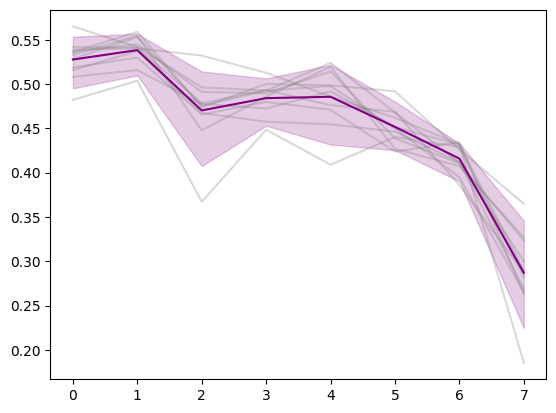

In [20]:
for i in range (0,len(accuracy_list_difconfig[0])):
    plt.plot(accuracy_list_difconfig[:,i],color="gray",alpha=0.3)
plt.plot(np.mean(accuracy_list_difconfig,axis=1),color="purple")
plt.fill_between(
    [0,1,2,3,4,5,6,7],
    np.percentile(accuracy_list_difconfig,95,axis=1),
    np.percentile(accuracy_list_difconfig,5,axis=1),
    color='purple',
    alpha=0.2,
)
plt.show()

In [23]:
# Logit calculation for multiple train subset configurations
### X is feature vector
X = uni_list
### Train-validation split
X_train=X[train_idx]
X_val=X[val_idx]
y_train=labels_encoded[train_idx]
y_val=labels_encoded[val_idx]
### Standard scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)### fit-transform on train dataset
X_val_scaled=scaler.transform(X_val)### transform on validation dataset


### Train subset configurations by setting sampling interval
interval_list=[1,3,6,9,12,15,18,21,24,27,30]
def compute_logits(i):
    X_selected = X_train_scaled[::i]### Train subset
    y_selected = y_train[::i]### Labels for train subset

    ros = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = ros.fit_resample(X_selected, y_selected)

    clf = OneVsRestClassifier(
        LogisticRegression(max_iter=1000)
    )
    clf.fit(X_resampled, y_resampled)

    logits = clf.decision_function(X_val_scaled)### Calculate logits on validation dataset
    return logits


logits_list_uni = Parallel(
    n_jobs=-1,
    backend="loky",
)(
    delayed(compute_logits)(i)
    for i in tqdm.tqdm(interval_list)
)
logits_list_uni=np.array(logits_list_uni)
print("Output logits shape:",logits_list_uni.shape)
print("Accuracy for each train subset configuration:")
pred_classes_uni=np.array([[np.argmax(logits_list_uni[i][j]) for j in range (0,1340)] for i in range (0,11)])
for i in range (0,11):
    print(np.sum(pred_classes_uni[i]==y_val)/1340)

100%|██████████| 11/11 [00:00<00:00, 7300.21it/s]


Output logits shape: (11, 1340, 7)
Accuracy for each train subset configuration:
0.6656716417910448
0.6365671641791045
0.6813432835820895
0.6253731343283582
0.6783582089552239
0.6298507462686567
0.6425373134328358
0.6917910447761194
0.6537313432835821
0.5895522388059702
0.6313432835820896


In [24]:
# Logit calculation for multiple train subset configurations
### X is feature vector
X = conch_list
### Train-validation split
X_train=X[train_idx]
X_val=X[val_idx]
y_train=labels_encoded[train_idx]
y_val=labels_encoded[val_idx]
### Standard scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)### fit-transform on train dataset
X_val_scaled=scaler.transform(X_val)### transform on validation dataset


### Train subset configurations by setting sampling interval
interval_list=[1,3,6,9,12,15,18,21,24,27,30]
def compute_logits(i):
    X_selected = X_train_scaled[::i]### Train subset
    y_selected = y_train[::i]### Labels for train subset

    ros = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = ros.fit_resample(X_selected, y_selected)

    clf = OneVsRestClassifier(
        LogisticRegression(max_iter=1000)
    )
    clf.fit(X_resampled, y_resampled)

    logits = clf.decision_function(X_val_scaled)### Calculate logits on validation dataset
    return logits


logits_list_conch = Parallel(
    n_jobs=-1,
    backend="loky",
)(
    delayed(compute_logits)(i)
    for i in tqdm.tqdm(interval_list)
)
logits_list_conch=np.array(logits_list_conch)
print("Output logits shape:",logits_list_conch.shape)
print("Accuracy for each train subset configuration:")
pred_classes_conch=np.array([[np.argmax(logits_list_conch[i][j]) for j in range (0,1340)] for i in range (0,11)])
for i in range (0,11):
    print(np.sum(pred_classes_conch[i]==y_val)/1340)

100%|██████████| 11/11 [00:00<00:00, 7349.05it/s]


Output logits shape: (11, 1340, 7)
Accuracy for each train subset configuration:
0.7
0.6582089552238806
0.6664179104477612
0.6626865671641791
0.608955223880597
0.6171641791044776
0.6268656716417911
0.6171641791044776
0.5843283582089552
0.5455223880597015
0.5843283582089552


### First we review combination with default TOP parameters.

In [25]:
print("T+C")
logits_list_tdaconch=np.array(logits_list_conch)+np.array(logits_list_default)
pred_classes_tdaconch=np.array([[np.argmax(logits_list_tdaconch[i][j]) for j in range (0,1340)] for i in range (0,11)])
for i in range (0,11):
    print(np.sum(pred_classes_tdaconch[i]==y_val)/1340)
print("U+T")
logits_list_unitda=np.array(logits_list_default)+np.array(logits_list_uni)
pred_classes_unitda=np.array([[np.argmax(logits_list_unitda[i][j]) for j in range (0,1340)] for i in range (0,11)])
for i in range (0,11):
    print(np.sum(pred_classes_unitda[i]==y_val)/1340)
print("U+C")
logits_list_uniconch=np.array(logits_list_conch)+np.array(logits_list_uni)
pred_classes_uniconch=np.array([[np.argmax(logits_list_uniconch[i][j]) for j in range (0,1340)] for i in range (0,11)])
for i in range (0,11):
    print(np.sum(pred_classes_uniconch[i]==y_val)/1340)
print("full")
logits_list_unitdaconch=np.array(logits_list_uni)+np.array(logits_list_default)+np.array(logits_list_conch)
pred_classes_unitdaconch=np.array([[np.argmax(logits_list_unitdaconch[i][j]) for j in range (0,1340)] for i in range (0,11)])
for i in range (0,11):
    print(np.sum(pred_classes_unitdaconch[i]==y_val)/1340)


T+C
0.6365671641791045
0.6537313432835821
0.6485074626865671
0.6738805970149254
0.6619402985074627
0.6529850746268657
0.6619402985074627
0.6597014925373135
0.6231343283582089
0.585820895522388
0.6276119402985074
U+T
0.6567164179104478
0.6462686567164179
0.6567164179104478
0.6626865671641791
0.6843283582089552
0.6425373134328358
0.6604477611940298
0.667910447761194
0.6582089552238806
0.6164179104477612
0.6283582089552239
U+C
0.6955223880597015
0.6798507462686567
0.7171641791044776
0.6656716417910448
0.6776119402985075
0.6828358208955224
0.6686567164179105
0.6977611940298507
0.6514925373134328
0.5962686567164179
0.6455223880597015
full
0.6843283582089552
0.6835820895522388
0.6985074626865672
0.685820895522388
0.7029850746268657
0.6940298507462687
0.691044776119403
0.6970149253731344
0.6619402985074627
0.6126865671641791
0.6582089552238806


In [26]:
### when we do not apply dimred
embedding_tda_list=logits_list_default
embedding_uni_list=logits_list_uni
embedding_conch_list=logits_list_conch
embedding_tdaconch_list=logits_list_tdaconch
embedding_unitda_list=logits_list_unitda
embedding_uniconch_list=logits_list_uniconch
embedding_uniconchtda_list=logits_list_unitdaconch

In [27]:
### Calculation of trustworthiness for all pairs in the embedding list
def trustworthiness_matrix(embedding_list, n_jobs=-1,n_neighbors=5):
    n = len(embedding_list)

    def compute_row_trust(j):
        return [trustworthiness(embedding_list[i], embedding_list[j],n_neighbors=n_neighbors) for i in range(n)]### calculates trustworthiness for one row.

    results = Parallel(n_jobs=n_jobs)(
        delayed(compute_row_trust)(j) for j in tqdm.tqdm(range(n))### calculates trustworthiness for all pairs
    )

    return np.array(results)


### Trustworthiness

Neighborhood size: 5


100%|██████████| 11/11 [00:00<00:00, 6026.30it/s]


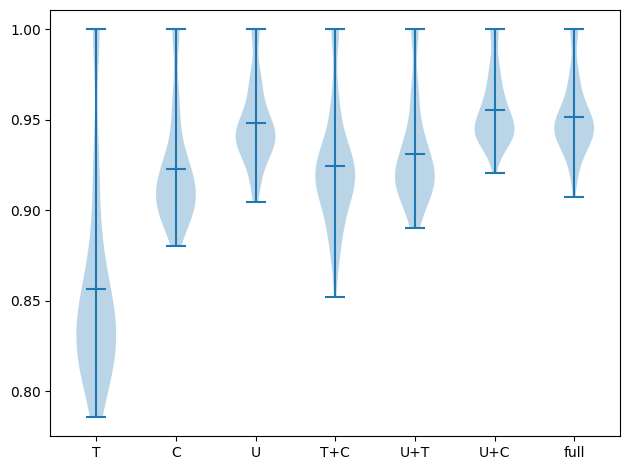

Neighborhood size: 55


100%|██████████| 11/11 [00:00<00:00, 7174.21it/s]


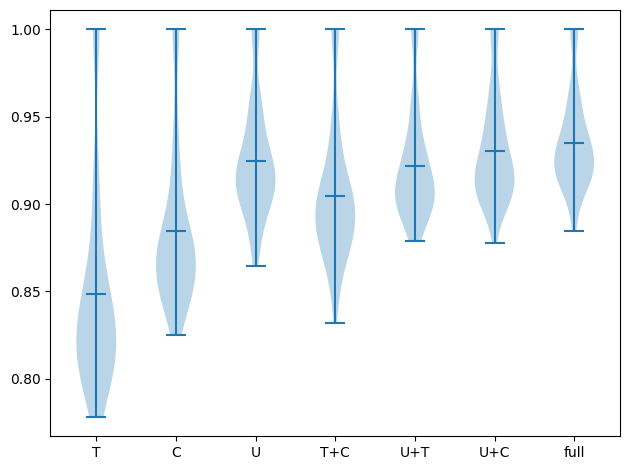

Neighborhood size: 105


100%|██████████| 11/11 [00:00<00:00, 6123.07it/s]


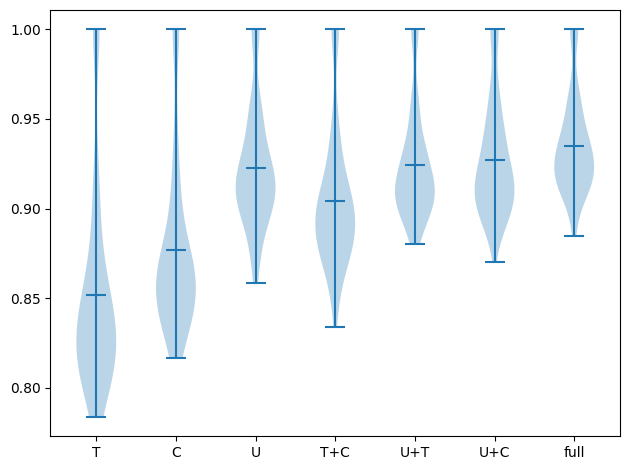

Neighborhood size: 155


100%|██████████| 11/11 [00:00<00:00, 5321.49it/s]


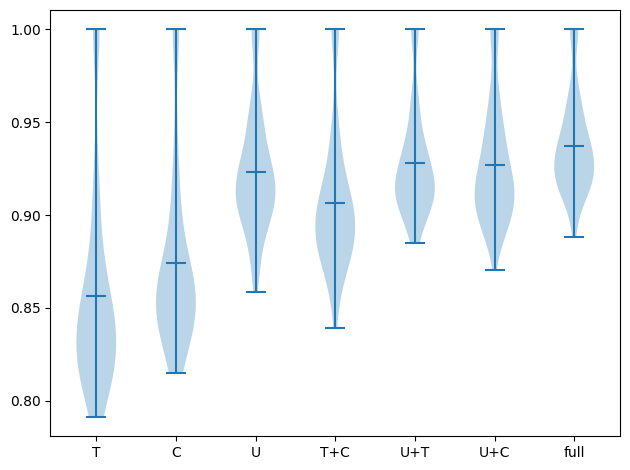

Neighborhood size: 205


100%|██████████| 11/11 [00:00<00:00, 8451.61it/s]


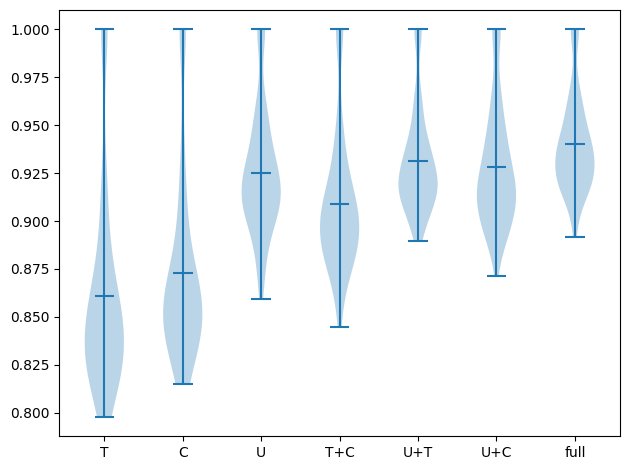

Neighborhood size: 255


100%|██████████| 11/11 [00:00<00:00, 5969.38it/s]


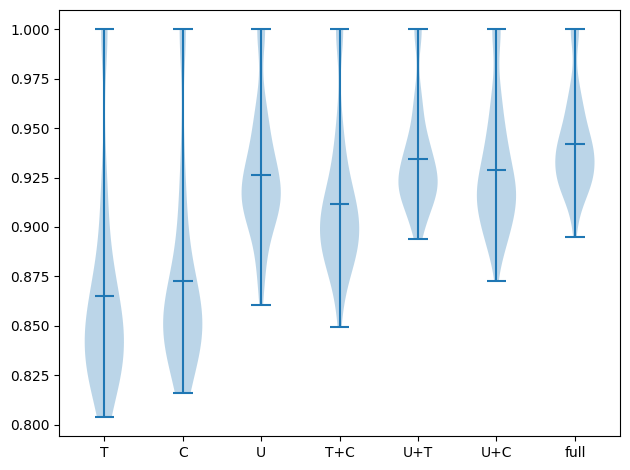

Neighborhood size: 305


100%|██████████| 11/11 [00:00<00:00, 6227.20it/s]


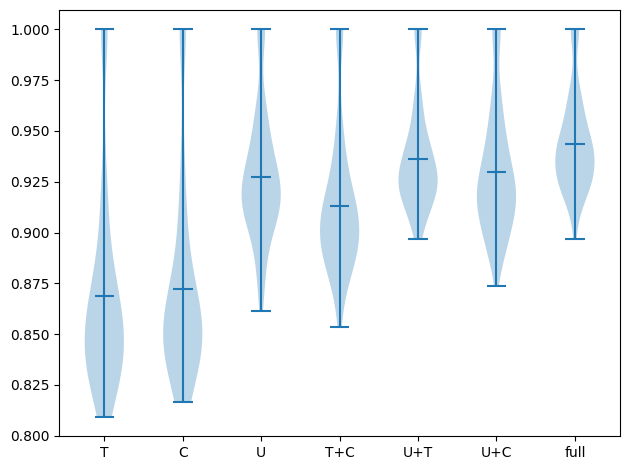

Neighborhood size: 355


100%|██████████| 11/11 [00:00<00:00, 5087.93it/s]


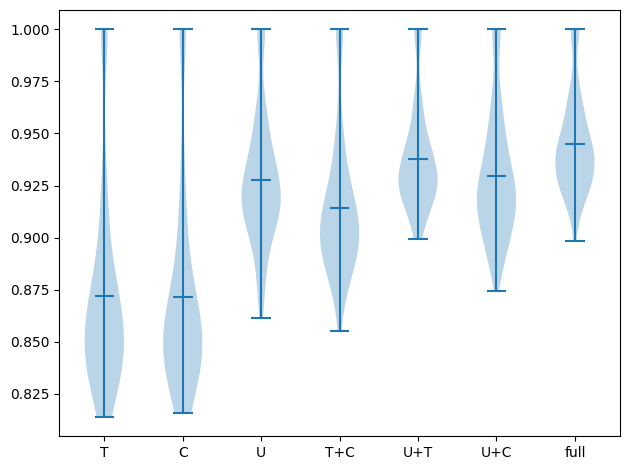

In [35]:
### Violin plot of the results with different neighborhood sizes.
for nbd_num in range (5,400,50):### We try different neighborhood sizes
    print("Neighborhood size:",nbd_num)
    trust_unitda=trustworthiness_matrix(embedding_unitda_list,n_neighbors=nbd_num).flatten()
    trust_uniconch=trustworthiness_matrix(embedding_uniconch_list,n_neighbors=nbd_num).flatten()
    trust_uniconchtda=trustworthiness_matrix(embedding_uniconchtda_list,n_neighbors=nbd_num).flatten()
    trust_tda=trustworthiness_matrix(embedding_tda_list,n_neighbors=nbd_num).flatten()
    trust_uni=trustworthiness_matrix(embedding_uni_list,n_neighbors=nbd_num).flatten()
    trust_conch=trustworthiness_matrix(embedding_conch_list,n_neighbors=nbd_num).flatten()
    trust_tdaconch=trustworthiness_matrix(embedding_tdaconch_list,n_neighbors=nbd_num).flatten()

    label_list=['T','C','U','T+C','U+T','U+C','full']
    data_list=[trust_tda,trust_conch,trust_uni,trust_tdaconch,trust_unitda,trust_uniconch,trust_uniconchtda]
    n_series=7
    positions = np.arange(1, len(data_list) + 1)

    parts = plt.violinplot(
        data_list,
        positions=positions,
        showmeans=True,     # mean
        showmedians=False,   
        showextrema=True    # min/max
    )

    plt.xticks(positions, label_list)

    plt.tight_layout()
    plt.show()

### We can see from the results above that U+T, U+C, and full are consistently performing better than others. Especially, U+T and full consistently have shorter lower distribution tails.

100%|██████████| 11/11 [00:00<00:00, 6427.60it/s]


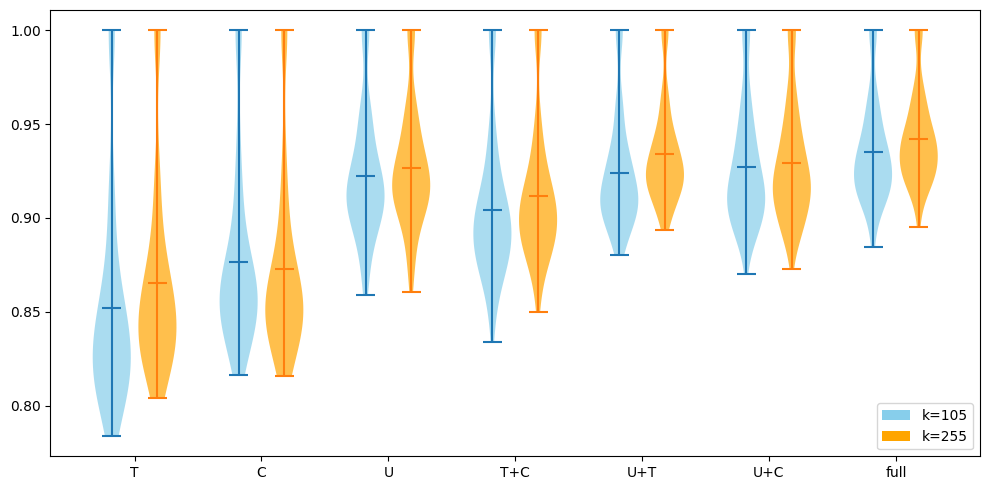

In [36]:
### paper figure k=105,255
### Violin plot of the results with different neighborhood sizes.
nbd_num=105
trust_unitda=trustworthiness_matrix(embedding_unitda_list,n_neighbors=nbd_num).flatten()
trust_uniconch=trustworthiness_matrix(embedding_uniconch_list,n_neighbors=nbd_num).flatten()
trust_uniconchtda=trustworthiness_matrix(embedding_uniconchtda_list,n_neighbors=nbd_num).flatten()
trust_tda=trustworthiness_matrix(embedding_tda_list,n_neighbors=nbd_num).flatten()
trust_uni=trustworthiness_matrix(embedding_uni_list,n_neighbors=nbd_num).flatten()
trust_conch=trustworthiness_matrix(embedding_conch_list,n_neighbors=nbd_num).flatten()
trust_tdaconch=trustworthiness_matrix(embedding_tdaconch_list,n_neighbors=nbd_num).flatten()

nbd_num=255
trust_unitda2=trustworthiness_matrix(embedding_unitda_list,n_neighbors=nbd_num).flatten()
trust_uniconch2=trustworthiness_matrix(embedding_uniconch_list,n_neighbors=nbd_num).flatten()
trust_uniconchtda2=trustworthiness_matrix(embedding_uniconchtda_list,n_neighbors=nbd_num).flatten()
trust_tda2=trustworthiness_matrix(embedding_tda_list,n_neighbors=nbd_num).flatten()
trust_uni2=trustworthiness_matrix(embedding_uni_list,n_neighbors=nbd_num).flatten()
trust_conch2=trustworthiness_matrix(embedding_conch_list,n_neighbors=nbd_num).flatten()
trust_tdaconch2=trustworthiness_matrix(embedding_tdaconch_list,n_neighbors=nbd_num).flatten()

label_list=['T','C','U','T+C','U+T','U+C','full']
data_list=[trust_tda,trust_conch,trust_uni,trust_tdaconch,trust_unitda,trust_uniconch,trust_uniconchtda]
data_list2=[trust_tda2,trust_conch2,trust_uni2,trust_tdaconch2,trust_unitda2,trust_uniconch2,trust_uniconchtda2]
n_series=7

positions = np.arange(1, n_series + 1)
offset = 0.18

fig, ax = plt.subplots(figsize=(10, 5))

parts_A = ax.violinplot(
    data_list,
    positions=positions - offset,
    widths=0.3,
    showmeans=True,
    showextrema=True
)

for pc in parts_A['bodies']:
    pc.set_facecolor('skyblue')
    pc.set_alpha(0.7)

parts_B = ax.violinplot(
    data_list2,
    positions=positions + offset,
    widths=0.3,
    showmeans=True,
    showextrema=True
)

for pc in parts_B['bodies']:
    pc.set_facecolor('orange')
    pc.set_alpha(0.7)

ax.set_xticks(positions)
ax.set_xticklabels(label_list)

from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='skyblue', label='k=105'),
    Patch(facecolor='orange', label='k=255')
]

ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

### Pairwise trustworthiness

In [44]:
### X_high and X_low are input and output spaces, respectively
### We use notions from dimensionality reduction where trustworthiness is often used, but note that in our setting, X_high and X_low have the same dimensionality.

def local_trustworthiness(X_high, X_low, k):
    n = X_high.shape[0]

    ### Neighborhoods in X_high
    nn_high = NearestNeighbors(n_neighbors=n).fit(X_high)
    _, ind_high = nn_high.kneighbors(X_high)
    
    ### Neighborhoods in X_low
    nn_low = NearestNeighbors(n_neighbors=k+1).fit(X_low)
    _, ind_low = nn_low.kneighbors(X_low)

    ### Rank matrix in X_high
    rank = np.empty((n, n), dtype=int)
    for i in range(n):
        rank[i, ind_high[i]] = np.arange(n)

    ### Initialize local trustworthiness values
    local_T = np.ones(n)
    norm = 2.0 / (k * (2*n - 3*k - 1))

    for i in range(n):
        low_neighbors = ind_low[i, 1:]  # Exclude self
        # neighbors in X_low that are not neighbors in X_high
        false_neighbors = low_neighbors[rank[i, low_neighbors] > k]

        penalty = np.sum(rank[i, false_neighbors] - k)
        local_T[i] -= norm * penalty

    return local_T


def pairwise_local_trustworthiness_flatten_parallel(
    embedding_list,
    k,
    n_jobs=-1,
    verbose=0
):
    N = len(embedding_list)

    def _compute_pair(i, j):
        return local_trustworthiness(
            embedding_list[i],
            embedding_list[j],
            k
        )

    results = Parallel(
        n_jobs=n_jobs,
        backend="loky",
        verbose=verbose
    )(
        delayed(_compute_pair)(i, j)
        for i in range(N)
        for j in range(N)
    )

    return np.concatenate(results)

Neighborhood size: 5


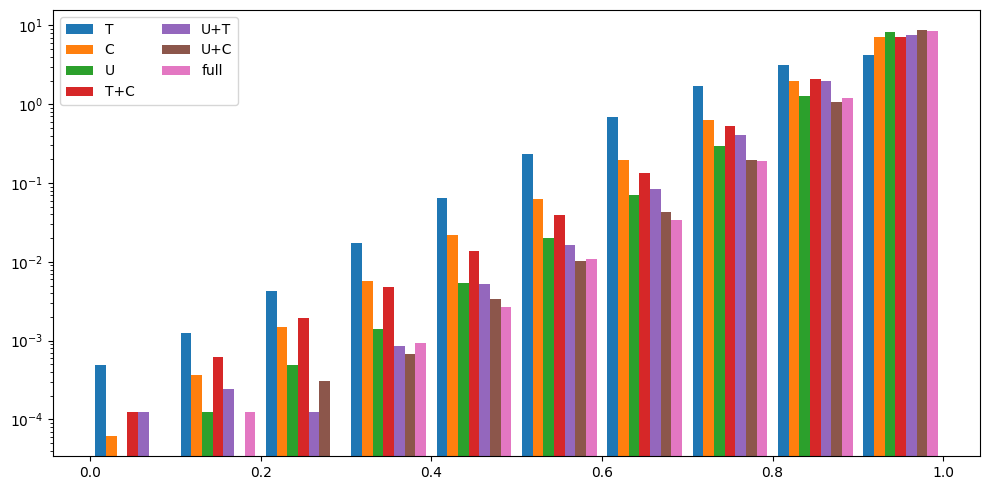

Neighborhood size: 55


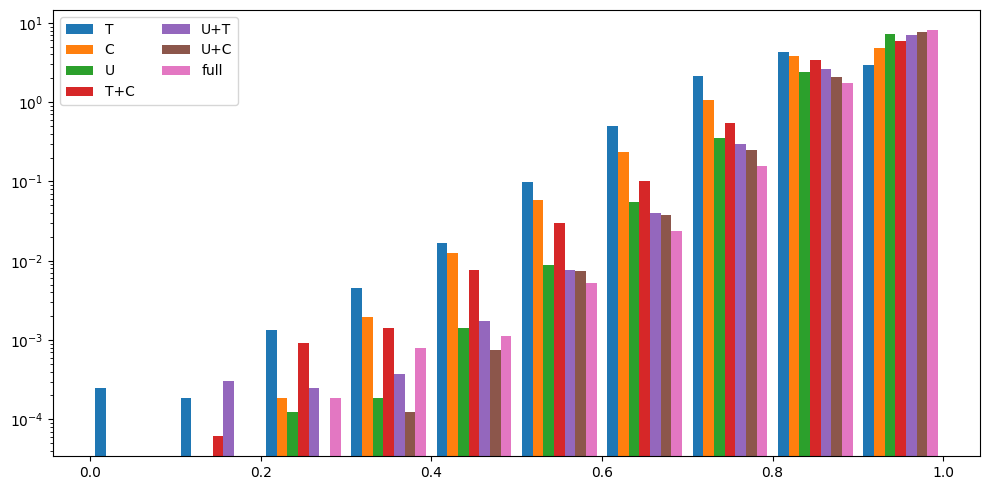

Neighborhood size: 105


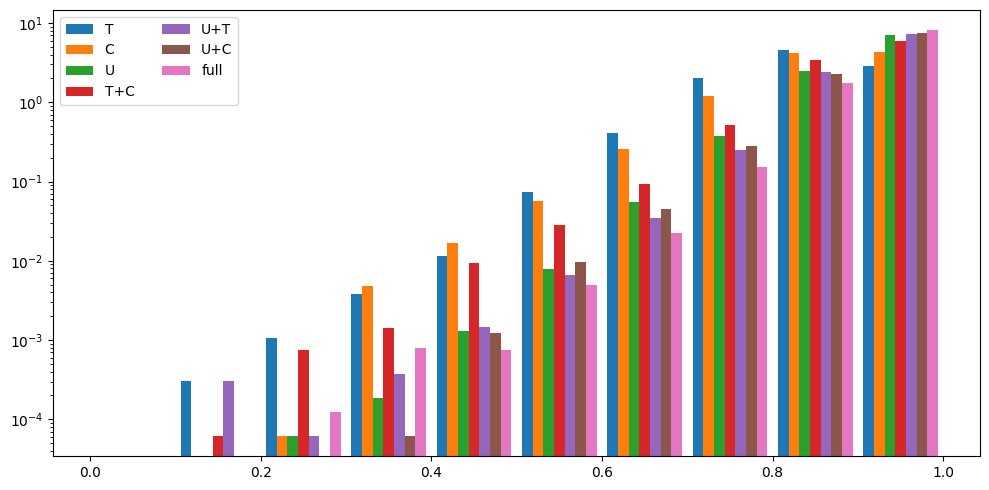

Neighborhood size: 155


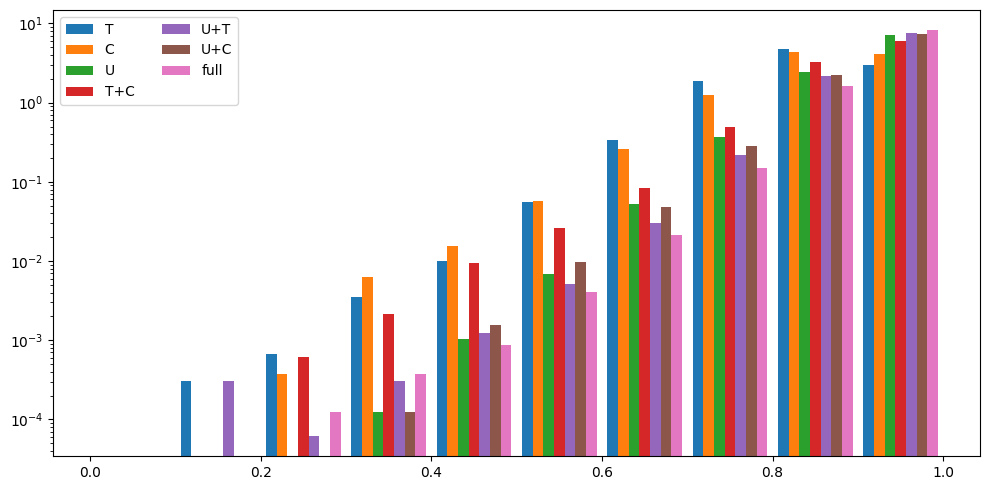

Neighborhood size: 205


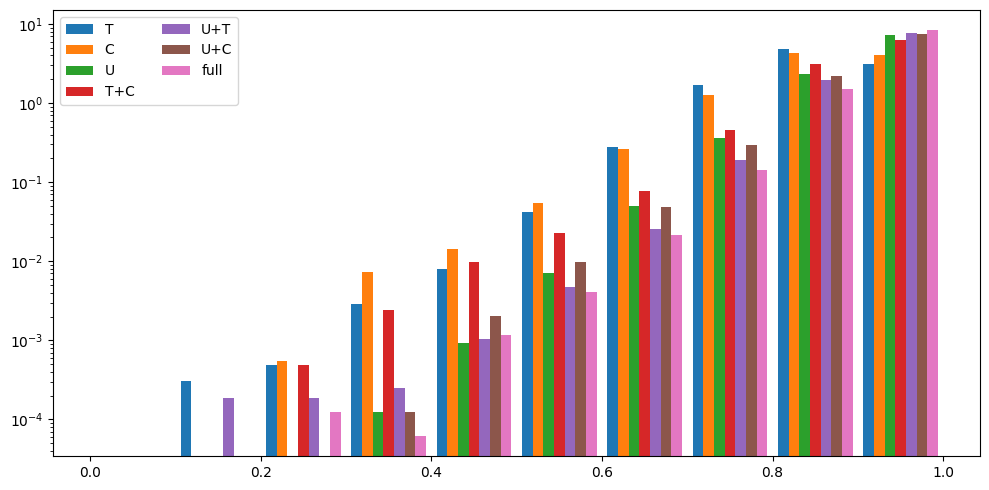

Neighborhood size: 255


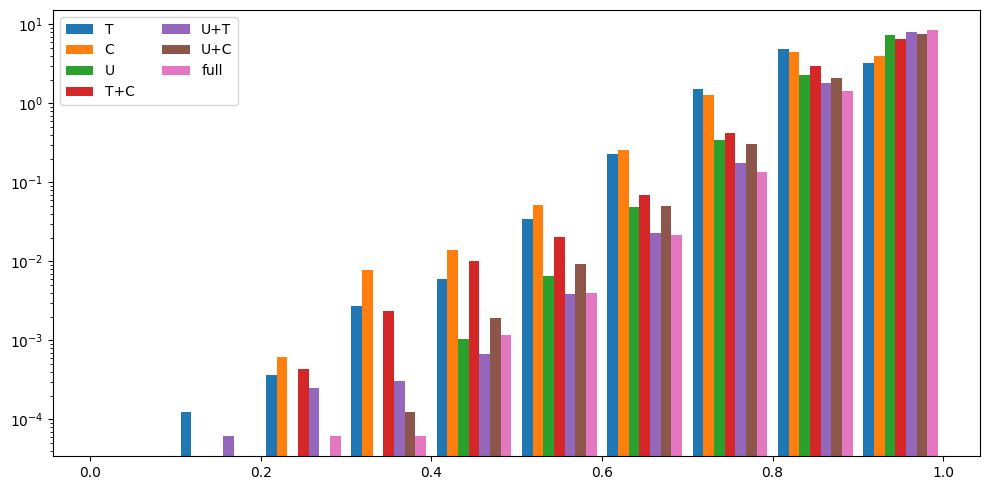

Neighborhood size: 305


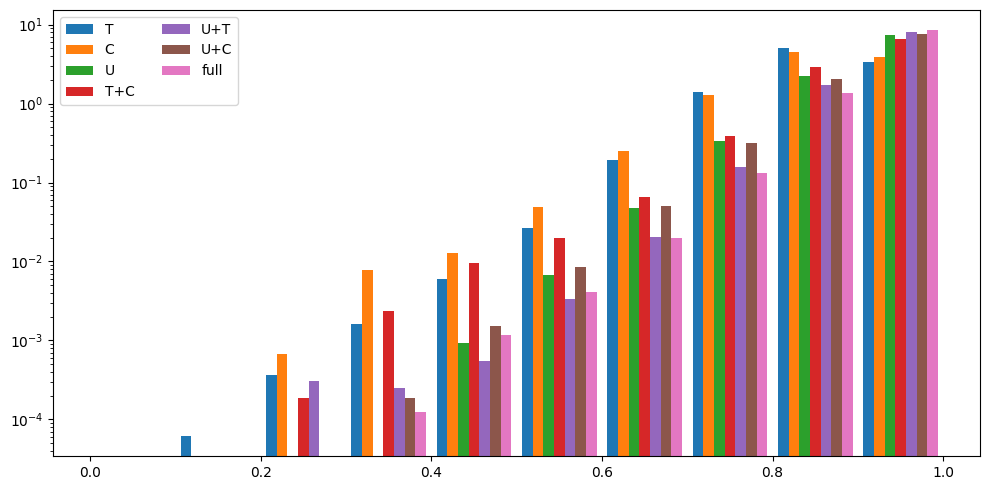

Neighborhood size: 355


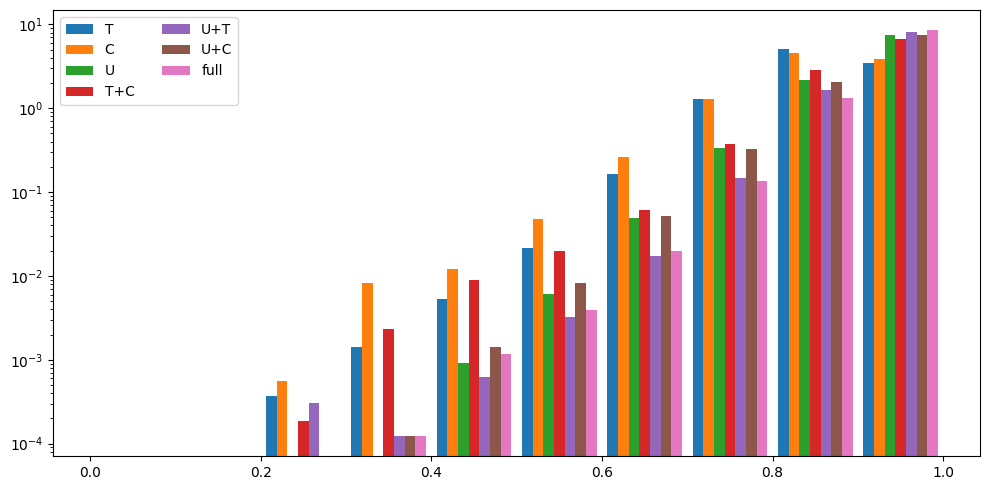

In [51]:
### Histogram of the results with different neighborhood sizes
for nbd_num in range (5,400,50):
    print("Neighborhood size:",nbd_num)
    trust_tda=pairwise_local_trustworthiness_flatten_parallel(embedding_tda_list,k=nbd_num)
    trust_conch=pairwise_local_trustworthiness_flatten_parallel(embedding_conch_list,k=nbd_num)
    trust_uni=pairwise_local_trustworthiness_flatten_parallel(embedding_uni_list,k=nbd_num)
    trust_tdaconch=pairwise_local_trustworthiness_flatten_parallel(embedding_tdaconch_list,k=nbd_num)
    trust_unitda=pairwise_local_trustworthiness_flatten_parallel(embedding_unitda_list,k=nbd_num)
    trust_uniconch=pairwise_local_trustworthiness_flatten_parallel(embedding_uniconch_list,k=nbd_num)
    trust_uniconchtda=pairwise_local_trustworthiness_flatten_parallel(embedding_uniconchtda_list,k=nbd_num)

    label_list=['T','C','U','T+C','U+T','U+C','full']
    data_list=[trust_tda,trust_conch,trust_uni,trust_tdaconch,trust_unitda, trust_uniconch,trust_uniconchtda]
    n_series=7
    bins = np.linspace(0.0, 1.0, 11)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bin_width = bins[1] - bins[0]

    ### Visualizations
    bar_width = bin_width / (n_series + 1)
    offsets = (
        np.arange(n_series) - (n_series - 1) / 2
    ) * bar_width

    plt.figure(figsize=(10, 5))

    for i, data in enumerate(data_list):
        hist, _ = np.histogram(data, bins=bins,density=True)
        plt.bar(
            bin_centers + offsets[i],
            hist,
            width=bar_width,
            label=label_list[i]
        )

    plt.yscale('log')
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

### We can see from the results above that, similar to the previous analysis, U+T, U+C, and full consistently have higher bars on the right part (high stability) and lower bars on the other part (low stability). Overall, U+T and full seem to be the best ones, followed by U+C.

### TOP parameter change analysis
We have seen so far that the combination of U and T has high stability performance. Now we change TOP parameters and see whether U+T's stability performance change or not.

In [52]:
logits_list_unitda_default=logits_list_default+logits_list_uni
logits_list_unitda_sizetwo=logits_list_sizetwo+logits_list_uni
logits_list_unitda_sizezero=logits_list_sizezero+logits_list_uni
logits_list_unitda_pdzero=logits_list_pdzero+logits_list_uni
logits_list_unitda_pdzerohalf=logits_list_pdzerohalf+logits_list_uni
logits_list_unitda_pdzerotenpercent=logits_list_pdzerotenpercent+logits_list_uni
logits_list_unitda_pdzerofivepercent=logits_list_pdzerofivepercent+logits_list_uni
logits_list_unitda_pdzerotwopercent=logits_list_pdzerotwopercent+logits_list_uni

In [53]:
logits_list_unitda_default.shape

(11, 1340, 7)

In [54]:
### standalone T accuracy droped with pruning. what about U+T
accuracy_list_default=[]
pred_classes=np.array([[np.argmax(logits_list_unitda_default[i][j]) for j in range (0,1340)] for i in range (0,11)])
for i in range (0,11):
    accuracy_list_default.append(np.sum(pred_classes[i]==y_val)/1340)
accuracy_list_sizetwo=[]
pred_classes=np.array([[np.argmax(logits_list_unitda_sizetwo[i][j]) for j in range (0,1340)] for i in range (0,11)])
for i in range (0,11):
    accuracy_list_sizetwo.append(np.sum(pred_classes[i]==y_val)/1340)
accuracy_list_sizezero=[]
pred_classes=np.array([[np.argmax(logits_list_unitda_sizezero[i][j]) for j in range (0,1340)] for i in range (0,11)])
for i in range (0,11):
    accuracy_list_sizezero.append(np.sum(pred_classes[i]==y_val)/1340)
accuracy_list_pdzero=[]
pred_classes=np.array([[np.argmax(logits_list_unitda_pdzero[i][j]) for j in range (0,1340)] for i in range (0,11)])
for i in range (0,11):
    accuracy_list_pdzero.append(np.sum(pred_classes[i]==y_val)/1340)
accuracy_list_pdzerohalf=[]
pred_classes=np.array([[np.argmax(logits_list_unitda_pdzerohalf[i][j]) for j in range (0,1340)] for i in range (0,11)])
for i in range (0,11):
    accuracy_list_pdzerohalf.append(np.sum(pred_classes[i]==y_val)/1340)
accuracy_list_pdzerotenpercent=[]
pred_classes=np.array([[np.argmax(logits_list_unitda_pdzerotenpercent[i][j]) for j in range (0,1340)] for i in range (0,11)])
for i in range (0,11):
    accuracy_list_pdzerotenpercent.append(np.sum(pred_classes[i]==y_val)/1340)
accuracy_list_pdzerofivepercent=[]
pred_classes=np.array([[np.argmax(logits_list_unitda_pdzerofivepercent[i][j]) for j in range (0,1340)] for i in range (0,11)])
for i in range (0,11):
    accuracy_list_pdzerofivepercent.append(np.sum(pred_classes[i]==y_val)/1340)
accuracy_list_pdzerotwopercent=[]
pred_classes=np.array([[np.argmax(logits_list_unitda_pdzerotwopercent[i][j]) for j in range (0,1340)] for i in range (0,11)])
for i in range (0,11):
    accuracy_list_pdzerotwopercent.append(np.sum(pred_classes[i]==y_val)/1340)


In [55]:
accuracy_list_pruningUT=np.array([accuracy_list_default,accuracy_list_sizetwo,accuracy_list_sizezero,accuracy_list_pdzero,accuracy_list_pdzerohalf,accuracy_list_pdzerotenpercent,accuracy_list_pdzerofivepercent,accuracy_list_pdzerotwopercent])
accuracy_list_pruningUT.shape

(8, 11)

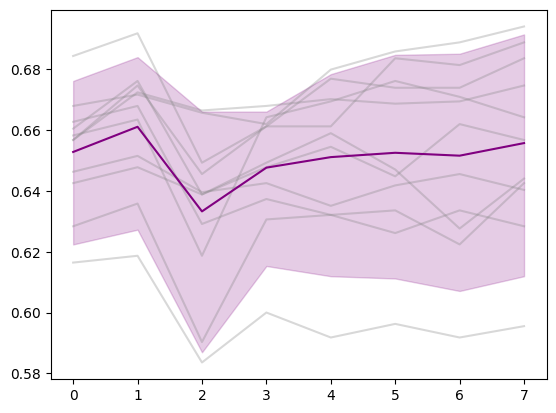

In [56]:
for i in range (0,len(accuracy_list_pruningUT[0])):
    plt.plot(accuracy_list_pruningUT[:,i],color="gray",alpha=0.3)
plt.plot(np.mean(accuracy_list_pruningUT,axis=1),color="purple")
plt.fill_between(
    [0,1,2,3,4,5,6,7],
    np.percentile(accuracy_list_pruningUT,95,axis=1),
    np.percentile(accuracy_list_pruningUT,5,axis=1),
    color='purple',
    alpha=0.2,
)
plt.show()

### U+T accuracy does not drop

Neighborhood size: 5


100%|██████████| 11/11 [00:00<00:00, 7598.38it/s]


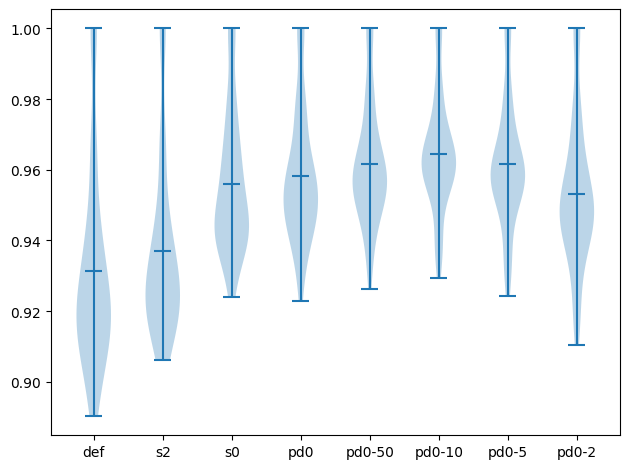

Neighborhood size: 55


100%|██████████| 11/11 [00:00<00:00, 6329.72it/s]


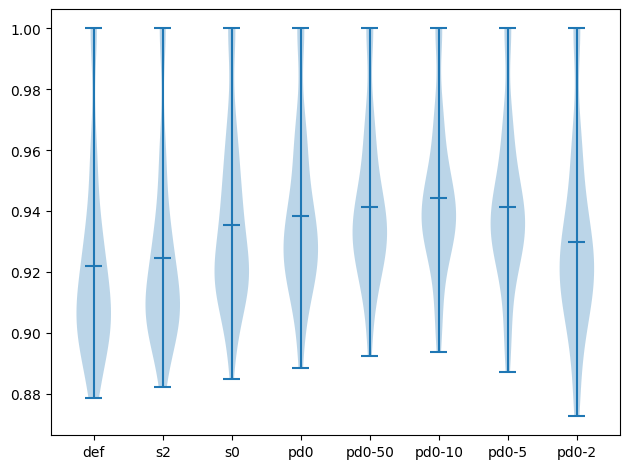

Neighborhood size: 105


100%|██████████| 11/11 [00:00<00:00, 6661.47it/s]


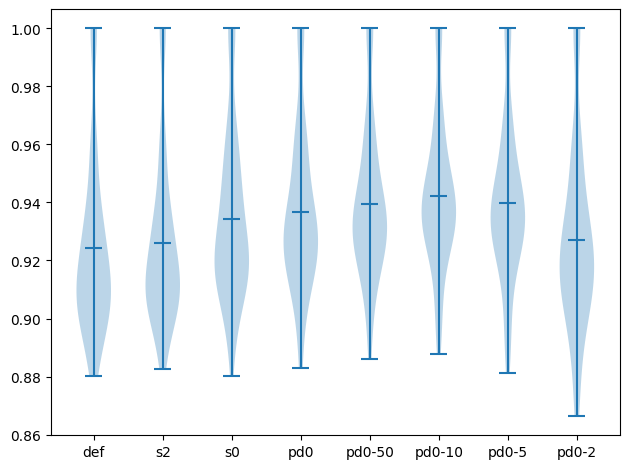

Neighborhood size: 155


100%|██████████| 11/11 [00:00<00:00, 7397.36it/s]


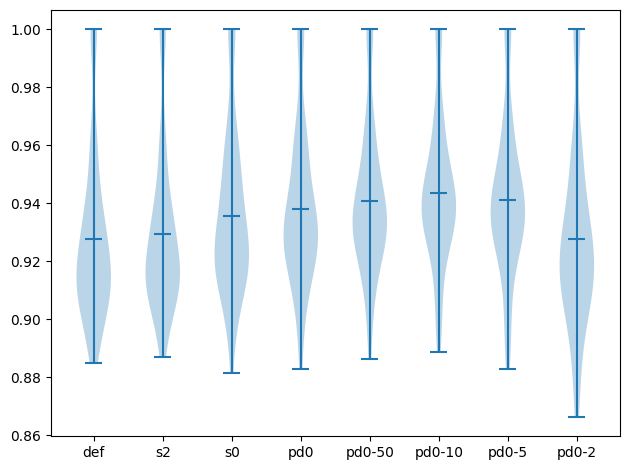

Neighborhood size: 205


100%|██████████| 11/11 [00:00<00:00, 6182.97it/s]


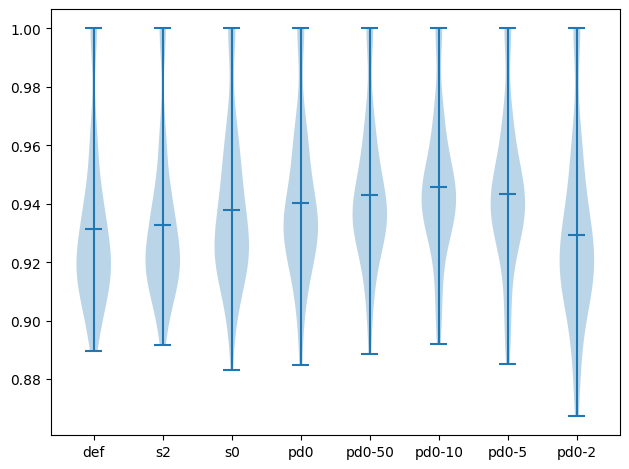

Neighborhood size: 255


100%|██████████| 11/11 [00:00<00:00, 10021.14it/s]


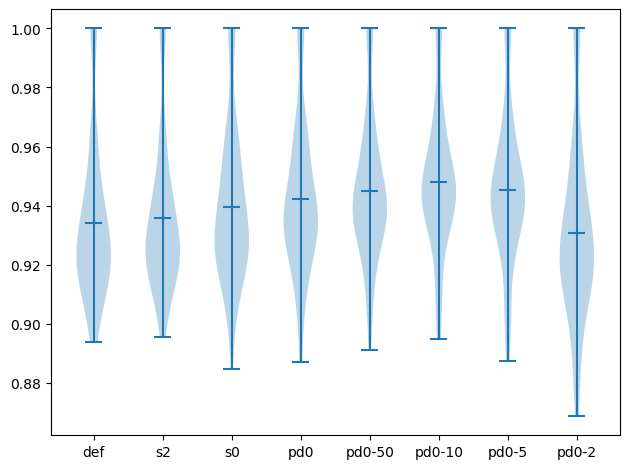

Neighborhood size: 305


100%|██████████| 11/11 [00:00<00:00, 5927.20it/s]


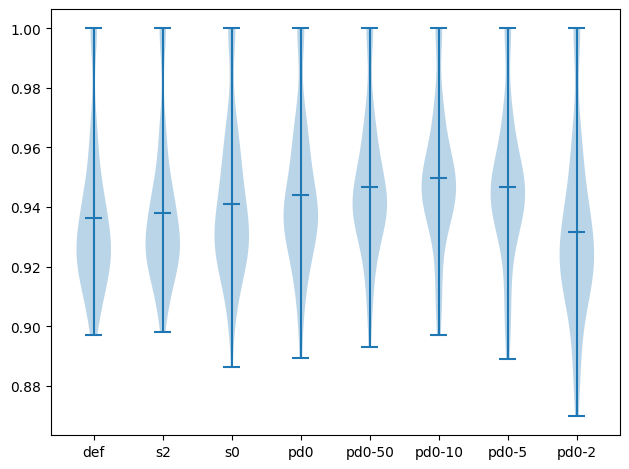

Neighborhood size: 355


100%|██████████| 11/11 [00:00<00:00, 6409.74it/s]


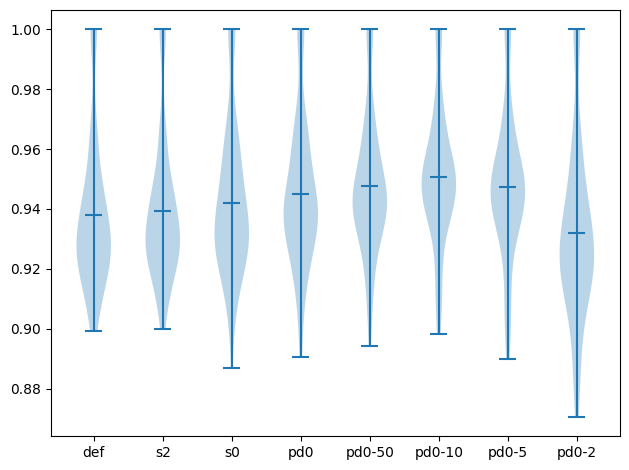

In [57]:
### Violin plot of the results with different neighborhood sizes.
for nbd_num in range (5,400,50):### We try different neighborhood sizes
    print("Neighborhood size:",nbd_num)
    trust_unitda_default=trustworthiness_matrix(logits_list_unitda_default,n_neighbors=nbd_num).flatten()
    trust_unitda_sizetwo=trustworthiness_matrix(logits_list_unitda_sizetwo,n_neighbors=nbd_num).flatten()
    trust_unitda_sizezero=trustworthiness_matrix(logits_list_unitda_sizezero,n_neighbors=nbd_num).flatten()
    trust_unitda_pdzero=trustworthiness_matrix(logits_list_unitda_pdzero,n_neighbors=nbd_num).flatten()
    trust_unitda_pdzerohalf=trustworthiness_matrix(logits_list_unitda_pdzerohalf,n_neighbors=nbd_num).flatten()
    trust_unitda_pdzerotenpercent=trustworthiness_matrix(logits_list_unitda_pdzerotenpercent,n_neighbors=nbd_num).flatten()
    trust_unitda_pdzerofivepercent=trustworthiness_matrix(logits_list_unitda_pdzerofivepercent,n_neighbors=nbd_num).flatten()
    trust_unitda_pdzerotwopercent=trustworthiness_matrix(logits_list_unitda_pdzerotwopercent,n_neighbors=nbd_num).flatten()

    label_list=['def','s2','s0','pd0','pd0-50','pd0-10','pd0-5','pd0-2']
    data_list=[trust_unitda_default,trust_unitda_sizetwo,trust_unitda_sizezero,trust_unitda_pdzero,trust_unitda_pdzerohalf,trust_unitda_pdzerotenpercent,trust_unitda_pdzerofivepercent, trust_unitda_pdzerotwopercent]
    n_series=8
    positions = np.arange(1, len(data_list) + 1)

    parts = plt.violinplot(
        data_list,
        positions=positions,
        showmeans=True,     # mean
        showmedians=False,   
        showextrema=True    # min/max
    )

    plt.xticks(positions, label_list)

    plt.tight_layout()
    plt.show()

Neighborhood size: 5


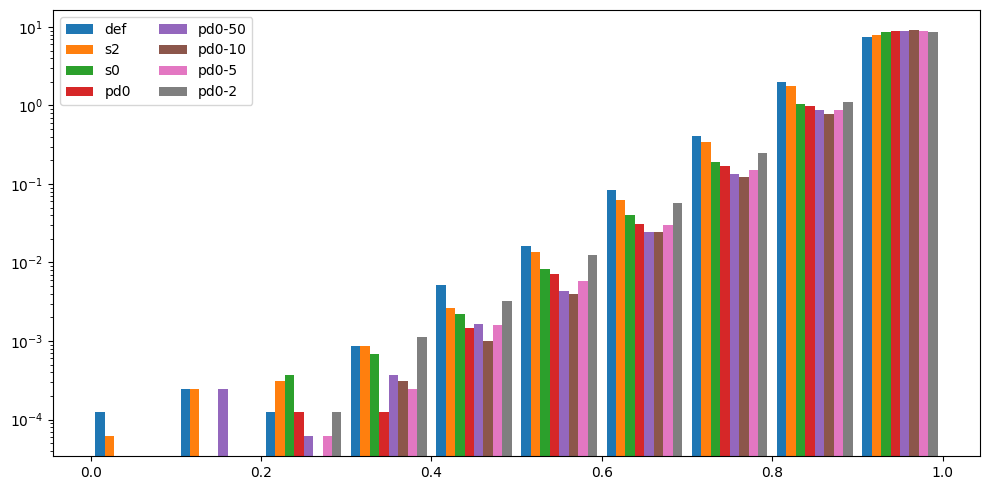

Neighborhood size: 55


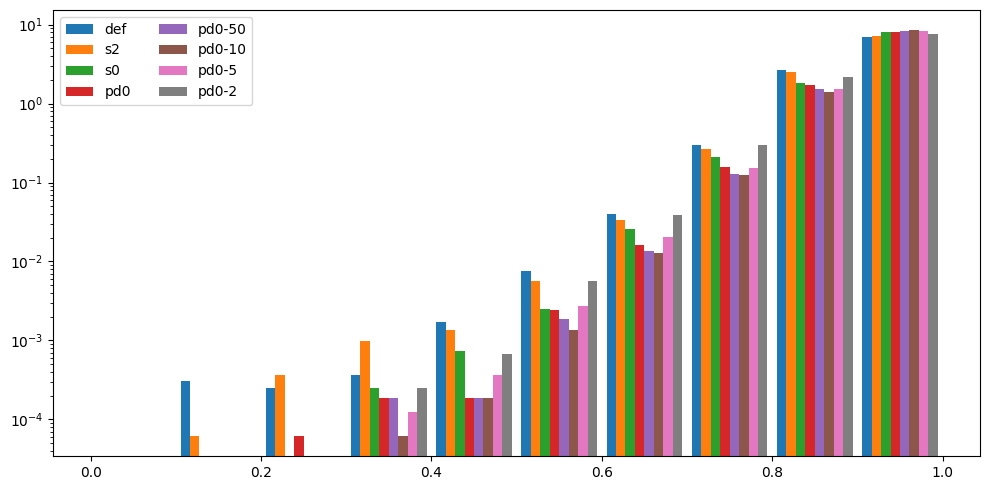

Neighborhood size: 105


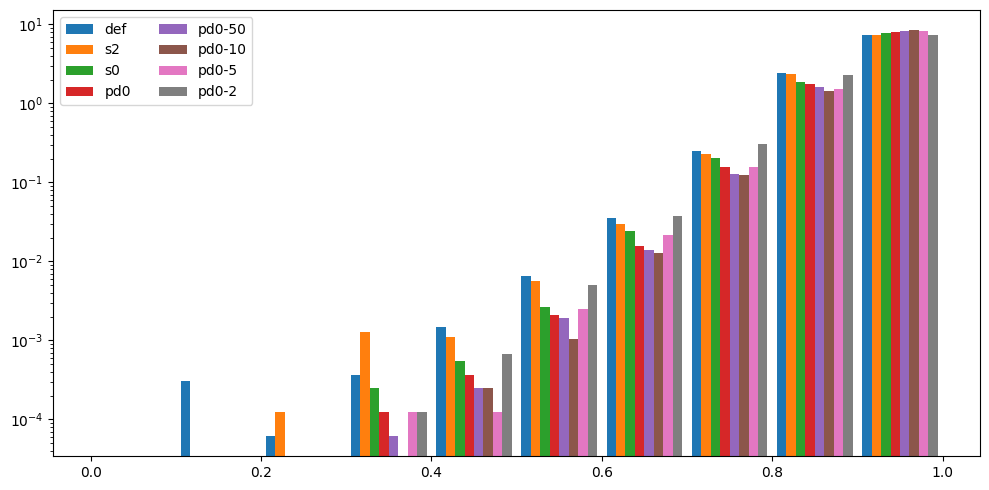

Neighborhood size: 155


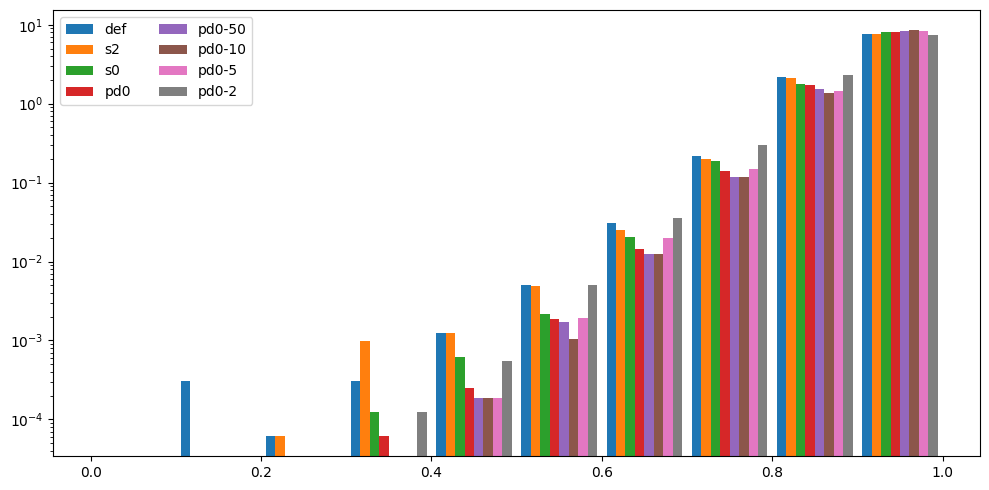

Neighborhood size: 205


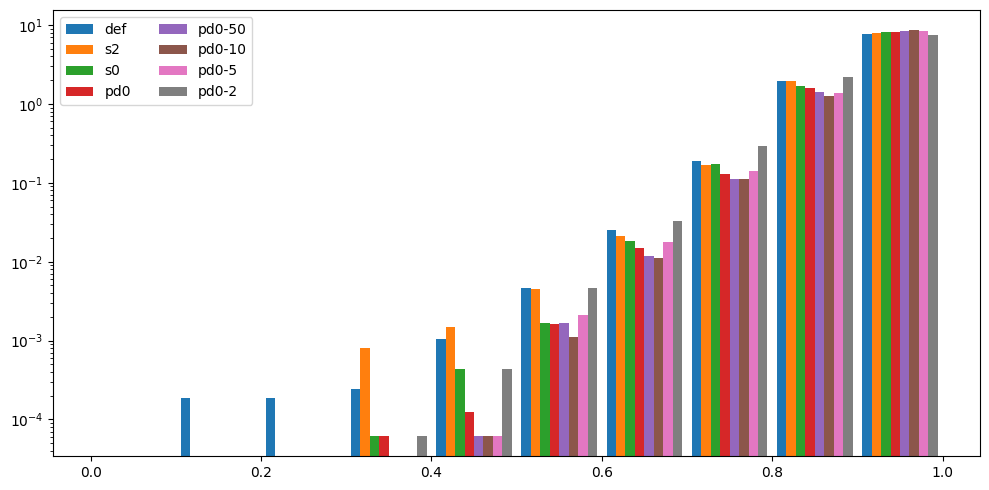

Neighborhood size: 255


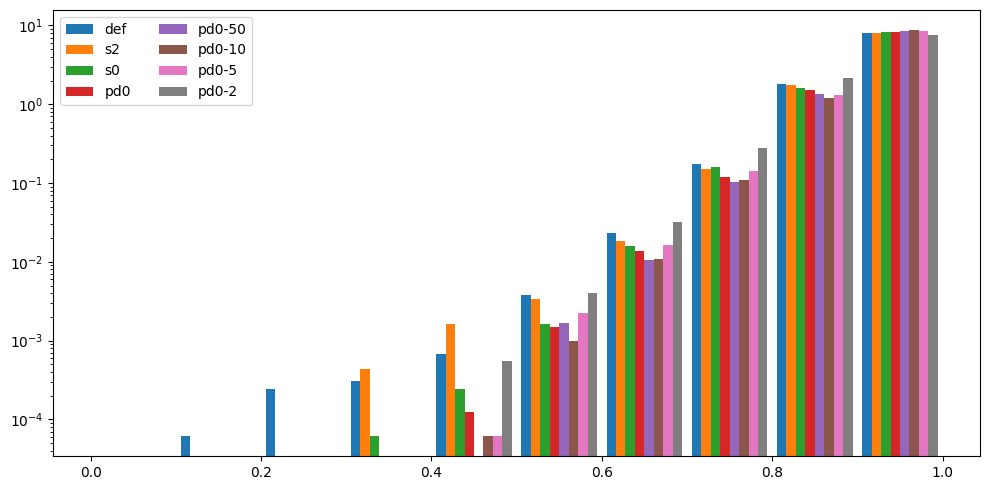

Neighborhood size: 305


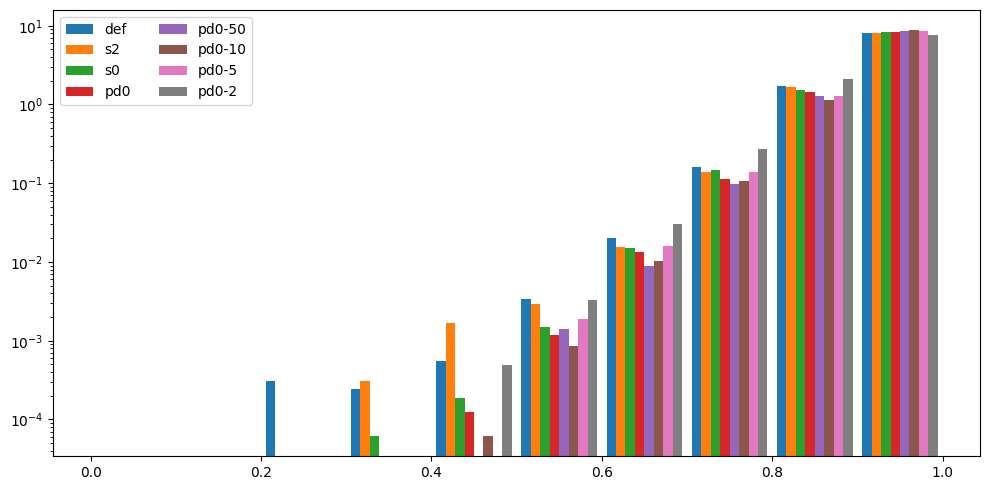

Neighborhood size: 355


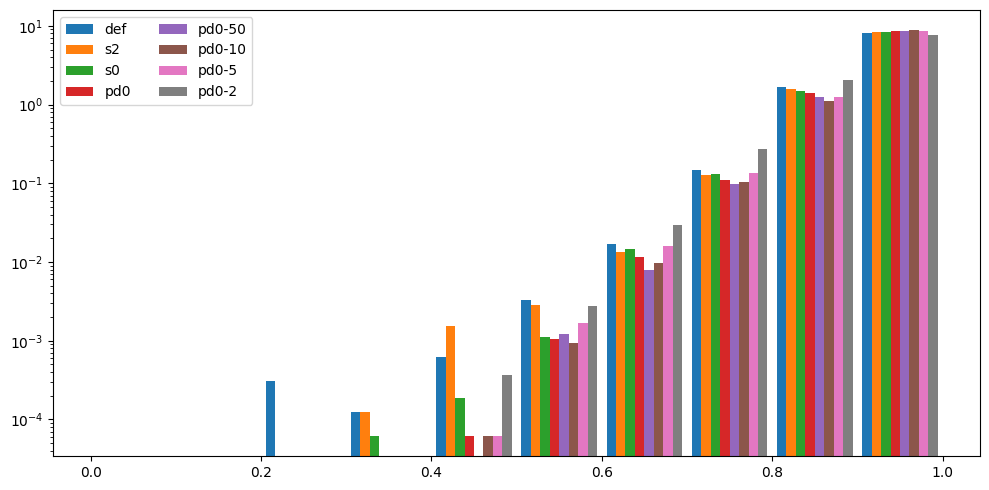

In [58]:
### Histogram of the results with different neighborhood sizes
for nbd_num in range (5,400,50):
    print("Neighborhood size:",nbd_num)
    trust_unitda_default=pairwise_local_trustworthiness_flatten_parallel(logits_list_unitda_default,k=nbd_num)
    trust_unitda_sizetwo=pairwise_local_trustworthiness_flatten_parallel(logits_list_unitda_sizetwo,k=nbd_num)
    trust_unitda_sizezero=pairwise_local_trustworthiness_flatten_parallel(logits_list_unitda_sizezero,k=nbd_num)
    trust_unitda_pdzero=pairwise_local_trustworthiness_flatten_parallel(logits_list_unitda_pdzero,k=nbd_num)
    trust_unitda_pdzerohalf=pairwise_local_trustworthiness_flatten_parallel(logits_list_unitda_pdzerohalf,k=nbd_num)
    trust_unitda_pdzerotenpercent=pairwise_local_trustworthiness_flatten_parallel(logits_list_unitda_pdzerotenpercent,k=nbd_num)
    trust_unitda_pdzerofivepercent=pairwise_local_trustworthiness_flatten_parallel(logits_list_unitda_pdzerofivepercent,k=nbd_num)
    trust_unitda_pdzerotwopercent=pairwise_local_trustworthiness_flatten_parallel(logits_list_unitda_pdzerotwopercent,k=nbd_num)

    label_list=['def','s2','s0','pd0','pd0-50','pd0-10','pd0-5','pd0-2']
    data_list=[trust_unitda_default,trust_unitda_sizetwo,trust_unitda_sizezero,trust_unitda_pdzero,trust_unitda_pdzerohalf,trust_unitda_pdzerotenpercent,trust_unitda_pdzerofivepercent, trust_unitda_pdzerotwopercent]
    n_series=8
    bins = np.linspace(0.0, 1.0, 11)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bin_width = bins[1] - bins[0]

    ### Visualizations
    bar_width = bin_width / (n_series + 1)
    offsets = (
        np.arange(n_series) - (n_series - 1) / 2
    ) * bar_width

    plt.figure(figsize=(10, 5))

    for i, data in enumerate(data_list):
        hist, _ = np.histogram(data, bins=bins,density=True)
        plt.bar(
            bin_centers + offsets[i],
            hist,
            width=bar_width,
            label=label_list[i]
        )

    plt.yscale('log')
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

### Now we will see the effect of trustworthiness improvements using stable point numbers.

In [59]:
params = [
    (i, j, k)
    for i, j, k in product(range(11), range(11), range(5, 400, 20))
]
def compute_trust_default(i, j, k):
    return local_trustworthiness(
        logits_list_unitda_default[i],
        logits_list_unitda_default[j],
        k=k
    )
def compute_trust_sizetwo(i, j, k):
    return local_trustworthiness(
        logits_list_unitda_sizetwo[i],
        logits_list_unitda_sizetwo[j],
        k=k
    )
def compute_trust_sizezero(i, j, k):
    return local_trustworthiness(
        logits_list_unitda_sizezero[i],
        logits_list_unitda_sizezero[j],
        k=k
    )
def compute_trust_pdzero(i, j, k):
    return local_trustworthiness(
        logits_list_unitda_pdzero[i],
        logits_list_unitda_pdzero[j],
        k=k
    )
def compute_trust_pdzerohalf(i, j, k):
    return local_trustworthiness(
        logits_list_unitda_pdzerohalf[i],
        logits_list_unitda_pdzerohalf[j],
        k=k
    )
def compute_trust_pdzerotenpercent(i, j, k):
    return local_trustworthiness(
        logits_list_unitda_pdzerotenpercent[i],
        logits_list_unitda_pdzerotenpercent[j],
        k=k
    )
def compute_trust_pdzerofivepercent(i, j, k):
    return local_trustworthiness(
        logits_list_unitda_pdzerofivepercent[i],
        logits_list_unitda_pdzerofivepercent[j],
        k=k
    )
def compute_trust_pdzerotwopercent(i, j, k):
    return local_trustworthiness(
        logits_list_unitda_pdzerotwopercent[i],
        logits_list_unitda_pdzerotwopercent[j],
        k=k
    )


def compute_trust_uni(i, j, k):
    return local_trustworthiness(
        embedding_uni_list[i],
        embedding_uni_list[j],
        k=k
    )

def compute_trust_uniconch(i, j, k):
    return local_trustworthiness(
        embedding_uniconch_list[i],
        embedding_uniconch_list[j],
        k=k
    )
def compute_trust_uniconchtda(i, j, k):
    return local_trustworthiness(
        embedding_uniconchtda_list[i],
        embedding_uniconchtda_list[j],
        k=k
    )


trust_list_uni = Parallel(n_jobs=-1)(
    delayed(compute_trust_uni)(i, j, k)
    for i, j, k in tqdm.tqdm(params)
)
trust_list_uniconch = Parallel(n_jobs=-1)(
    delayed(compute_trust_uniconch)(i, j, k)
    for i, j, k in tqdm.tqdm(params)
)
trust_list_uniconchtda = Parallel(n_jobs=-1)(
    delayed(compute_trust_uniconchtda)(i, j, k)
    for i, j, k in tqdm.tqdm(params)
)

trust_list_default = Parallel(n_jobs=-1)(
    delayed(compute_trust_default)(i, j, k)
    for i, j, k in tqdm.tqdm(params)
)
trust_list_sizetwo = Parallel(n_jobs=-1)(
    delayed(compute_trust_sizetwo)(i, j, k)
    for i, j, k in tqdm.tqdm(params)
)
trust_list_sizezero = Parallel(n_jobs=-1)(
    delayed(compute_trust_sizezero)(i, j, k)
    for i, j, k in tqdm.tqdm(params)
)
trust_list_pdzero = Parallel(n_jobs=-1)(
    delayed(compute_trust_pdzero)(i, j, k)
    for i, j, k in tqdm.tqdm(params)
)
trust_list_pdzerohalf = Parallel(n_jobs=-1)(
    delayed(compute_trust_pdzerohalf)(i, j, k)
    for i, j, k in tqdm.tqdm(params)
)
trust_list_pdzerotenpercent = Parallel(n_jobs=-1)(
    delayed(compute_trust_pdzerotenpercent)(i, j, k)
    for i, j, k in tqdm.tqdm(params)
)
trust_list_pdzerofivepercent = Parallel(n_jobs=-1)(
    delayed(compute_trust_pdzerofivepercent)(i, j, k)
    for i, j, k in tqdm.tqdm(params)
)
trust_list_pdzerotwopercent = Parallel(n_jobs=-1)(
    delayed(compute_trust_pdzerotwopercent)(i, j, k)
    for i, j, k in tqdm.tqdm(params)
)




100%|██████████| 2420/2420 [00:23<00:00, 103.78it/s]


In [60]:
np.array(trust_list_pdzerotwopercent).shape

(2420, 1340)

In [61]:
trust_list_uni=np.array(trust_list_uni)
trust_list_uniconch=np.array(trust_list_uniconch)
trust_list_uniconchtda=np.array(trust_list_uniconchtda)
trust_list_default=np.array(trust_list_default)
trust_list_sizetwo=np.array(trust_list_sizetwo)
trust_list_sizezero=np.array(trust_list_sizezero)
trust_list_pdzero=np.array(trust_list_pdzero)
trust_list_pdzerohalf=np.array(trust_list_pdzerohalf)
trust_list_pdzerotenpercent=np.array(trust_list_pdzerotenpercent)
trust_list_pdzerofivepercent=np.array(trust_list_pdzerofivepercent)
trust_list_pdzerotwoprecent=np.array(trust_list_pdzerotwopercent)

In [62]:
cmap = plt.get_cmap("magma")
colors = cmap(np.linspace(0.3, 0.55, 6))
print(colors)

[[0.390384 0.100379 0.501864 1.      ]
 [0.46964  0.132245 0.507809 1.      ]
 [0.550287 0.161158 0.505719 1.      ]
 [0.632805 0.187893 0.495332 1.      ]
 [0.716387 0.214982 0.47529  1.      ]
 [0.792427 0.244242 0.447543 1.      ]]


In [63]:
### We show figures without and with full model with default T.

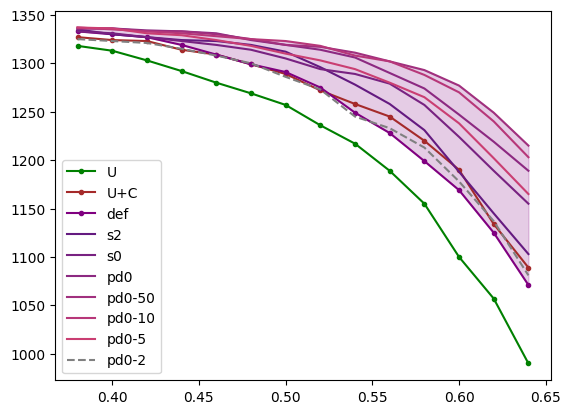

In [66]:
### others
trust_list_uni_min=np.min(trust_list_uni,axis=0)
trust_list_uniconch_min=np.min(trust_list_uniconch,axis=0)
trust_list_uniconchtda_min=np.min(trust_list_uniconchtda,axis=0)
###U+Ts
trust_list_default_min=np.min(trust_list_default,axis=0)
trust_list_sizetwo_min=np.min(trust_list_sizetwo,axis=0)
trust_list_sizezero_min=np.min(trust_list_sizezero,axis=0)
trust_list_pdzero_min=np.min(trust_list_pdzero,axis=0)
trust_list_pdzerohalf_min=np.min(trust_list_pdzerohalf,axis=0)
trust_list_pdzerotenpercent_min=np.min(trust_list_pdzerotenpercent,axis=0)
trust_list_pdzerofivepercent_min=np.min(trust_list_pdzerofivepercent,axis=0)
trust_list_pdzerotwopercent_min=np.min(trust_list_pdzerotwopercent,axis=0)
####################
stable_uni=[]
stable_uniconch=[]
stable_uniconchtda=[]
stable_default=[]
stable_sizetwo=[]
stable_sizezero=[]
stable_pdzero=[]
stable_pdzerohalf=[]
stable_pdzerotenpercent=[]
stable_pdzerofivepercent=[]
stable_pdzerotwopercent=[]
for trust_thres in np.arange(0,1,0.02):
    trust_spots_uni=np.where(trust_list_uni_min>trust_thres)[0]
    trust_spots_uniconch=np.where(trust_list_uniconch_min>trust_thres)[0]
    trust_spots_uniconchtda=np.where(trust_list_uniconchtda_min>trust_thres)[0]

    trust_spots_default=np.where(trust_list_default_min>trust_thres)[0]
    trust_spots_sizetwo=np.where(trust_list_sizetwo_min>trust_thres)[0]
    trust_spots_sizezero=np.where(trust_list_sizezero_min>trust_thres)[0]
    trust_spots_pdzero=np.where(trust_list_pdzero_min>trust_thres)[0]
    trust_spots_pdzerohalf=np.where(trust_list_pdzerohalf_min>trust_thres)[0]
    trust_spots_pdzerotenpercent=np.where(trust_list_pdzerotenpercent_min>trust_thres)[0]
    trust_spots_pdzerofivepercent=np.where(trust_list_pdzerofivepercent_min>trust_thres)[0]
    trust_spots_pdzerotwopercent=np.where(trust_list_pdzerotwopercent_min>trust_thres)[0]


    ### Record the number of stable points with each threshold value
    stable_uni.append(len(trust_spots_uni))
    stable_uniconch.append(len(trust_spots_uniconch))
    stable_uniconchtda.append(len(trust_spots_uniconchtda))

    stable_default.append(len(trust_spots_default))
    stable_sizetwo.append(len(trust_spots_sizetwo))
    stable_sizezero.append(len(trust_spots_sizezero))
    stable_pdzero.append(len(trust_spots_pdzero))
    stable_pdzerohalf.append(len(trust_spots_pdzerohalf))
    stable_pdzerotenpercent.append(len(trust_spots_pdzerotenpercent))
    stable_pdzerofivepercent.append(len(trust_spots_pdzerofivepercent))
    stable_pdzerotwopercent.append(len(trust_spots_pdzerotwopercent))
full_stable_list=np.array([stable_default,stable_sizetwo,stable_sizezero,stable_pdzero,stable_pdzerohalf,stable_pdzerotenpercent, stable_pdzerofivepercent,stable_pdzerotwopercent])
max_stable_list=np.max(full_stable_list,axis=0)
min_stable_list=np.min(full_stable_list,axis=0)
mask=np.where(max_stable_list>0.9*max_stable_list[0])
mask2=np.where(min_stable_list<0.99*min_stable_list[0])
mask3=np.intersect1d(mask[0],mask2[0])

utmulti_list=np.array([stable_default,stable_sizetwo,stable_sizezero,stable_pdzero,stable_pdzerohalf,stable_pdzerotenpercent, stable_pdzerofivepercent])
y_min=utmulti_list.min(axis=0)
y_max=utmulti_list.max(axis=0)

### Visualization
x=np.arange(0,1,0.02)[mask3]
plt.plot(x,np.array(stable_uni)[mask3],marker='.',label='U',color='green')
plt.plot(x,np.array(stable_uniconch)[mask3],marker='.',label='U+C',color='brown')
#plt.plot(x,np.array(stable_uniconchtda)[mask3],marker='.',label='full')

plt.plot(x,np.array(stable_default)[mask3],marker='.',label='def',color='purple')
plt.plot(x,np.array(stable_sizetwo)[mask3],label='s2',color=colors[0])
plt.plot(x,np.array(stable_sizezero)[mask3],label='s0',color=colors[1])
plt.plot(x,np.array(stable_pdzero)[mask3],label='pd0',color=colors[2])
plt.plot(x,np.array(stable_pdzerohalf)[mask3],label='pd0-50',color=colors[3])
plt.plot(x,np.array(stable_pdzerotenpercent)[mask3],label='pd0-10',color=colors[4])
plt.plot(x,np.array(stable_pdzerofivepercent)[mask3],label='pd0-5',color=colors[5])
plt.plot(x,np.array(stable_pdzerotwopercent)[mask3],label='pd0-2',color='gray',ls="--")
plt.fill_between(
    x,
    y_min[mask3],
    y_max[mask3],
    color='purple',
    alpha=0.2,
)

plt.legend()
plt.show()



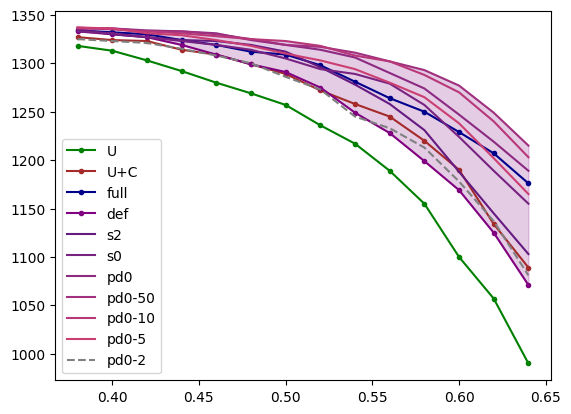

In [68]:
### others
trust_list_uni_min=np.min(trust_list_uni,axis=0)
trust_list_uniconch_min=np.min(trust_list_uniconch,axis=0)
trust_list_uniconchtda_min=np.min(trust_list_uniconchtda,axis=0)
###U+Ts
trust_list_default_min=np.min(trust_list_default,axis=0)
trust_list_sizetwo_min=np.min(trust_list_sizetwo,axis=0)
trust_list_sizezero_min=np.min(trust_list_sizezero,axis=0)
trust_list_pdzero_min=np.min(trust_list_pdzero,axis=0)
trust_list_pdzerohalf_min=np.min(trust_list_pdzerohalf,axis=0)
trust_list_pdzerotenpercent_min=np.min(trust_list_pdzerotenpercent,axis=0)
trust_list_pdzerofivepercent_min=np.min(trust_list_pdzerofivepercent,axis=0)
trust_list_pdzerotwopercent_min=np.min(trust_list_pdzerotwopercent,axis=0)
####################
stable_uni=[]
stable_uniconch=[]
stable_uniconchtda=[]
stable_default=[]
stable_sizetwo=[]
stable_sizezero=[]
stable_pdzero=[]
stable_pdzerohalf=[]
stable_pdzerotenpercent=[]
stable_pdzerofivepercent=[]
stable_pdzerotwopercent=[]
for trust_thres in np.arange(0,1,0.02):
    trust_spots_uni=np.where(trust_list_uni_min>trust_thres)[0]
    trust_spots_uniconch=np.where(trust_list_uniconch_min>trust_thres)[0]
    trust_spots_uniconchtda=np.where(trust_list_uniconchtda_min>trust_thres)[0]

    trust_spots_default=np.where(trust_list_default_min>trust_thres)[0]
    trust_spots_sizetwo=np.where(trust_list_sizetwo_min>trust_thres)[0]
    trust_spots_sizezero=np.where(trust_list_sizezero_min>trust_thres)[0]
    trust_spots_pdzero=np.where(trust_list_pdzero_min>trust_thres)[0]
    trust_spots_pdzerohalf=np.where(trust_list_pdzerohalf_min>trust_thres)[0]
    trust_spots_pdzerotenpercent=np.where(trust_list_pdzerotenpercent_min>trust_thres)[0]
    trust_spots_pdzerofivepercent=np.where(trust_list_pdzerofivepercent_min>trust_thres)[0]
    trust_spots_pdzerotwopercent=np.where(trust_list_pdzerotwopercent_min>trust_thres)[0]


    ### Record the number of stable points with each threshold value
    stable_uni.append(len(trust_spots_uni))
    stable_uniconch.append(len(trust_spots_uniconch))
    stable_uniconchtda.append(len(trust_spots_uniconchtda))

    stable_default.append(len(trust_spots_default))
    stable_sizetwo.append(len(trust_spots_sizetwo))
    stable_sizezero.append(len(trust_spots_sizezero))
    stable_pdzero.append(len(trust_spots_pdzero))
    stable_pdzerohalf.append(len(trust_spots_pdzerohalf))
    stable_pdzerotenpercent.append(len(trust_spots_pdzerotenpercent))
    stable_pdzerofivepercent.append(len(trust_spots_pdzerofivepercent))
    stable_pdzerotwopercent.append(len(trust_spots_pdzerotwopercent))
full_stable_list=np.array([stable_default,stable_sizetwo,stable_sizezero,stable_pdzero,stable_pdzerohalf,stable_pdzerotenpercent, stable_pdzerofivepercent,stable_pdzerotwopercent])
max_stable_list=np.max(full_stable_list,axis=0)
min_stable_list=np.min(full_stable_list,axis=0)
mask=np.where(max_stable_list>0.9*max_stable_list[0])
mask2=np.where(min_stable_list<0.99*min_stable_list[0])
mask3=np.intersect1d(mask[0],mask2[0])

utmulti_list=np.array([stable_default,stable_sizetwo,stable_sizezero,stable_pdzero,stable_pdzerohalf,stable_pdzerotenpercent, stable_pdzerofivepercent])
y_min=utmulti_list.min(axis=0)
y_max=utmulti_list.max(axis=0)

### Visualization
x=np.arange(0,1,0.02)[mask3]
plt.plot(x,np.array(stable_uni)[mask3],marker='.',label='U',color='green')
plt.plot(x,np.array(stable_uniconch)[mask3],marker='.',label='U+C',color='brown')
plt.plot(x,np.array(stable_uniconchtda)[mask3],marker='.',label='full',color="darkblue")

plt.plot(x,np.array(stable_default)[mask3],marker='.',label='def',color='purple')
plt.plot(x,np.array(stable_sizetwo)[mask3],label='s2',color=colors[0])
plt.plot(x,np.array(stable_sizezero)[mask3],label='s0',color=colors[1])
plt.plot(x,np.array(stable_pdzero)[mask3],label='pd0',color=colors[2])
plt.plot(x,np.array(stable_pdzerohalf)[mask3],label='pd0-50',color=colors[3])
plt.plot(x,np.array(stable_pdzerotenpercent)[mask3],label='pd0-10',color=colors[4])
plt.plot(x,np.array(stable_pdzerofivepercent)[mask3],label='pd0-5',color=colors[5])
plt.plot(x,np.array(stable_pdzerotwopercent)[mask3],label='pd0-2',color='gray',ls="--")
plt.fill_between(
    x,
    y_min[mask3],
    y_max[mask3],
    color='purple',
    alpha=0.2,
)

plt.legend()
plt.show()



### 10-percentile

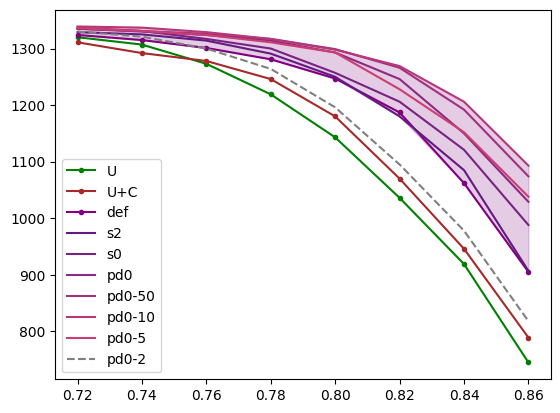

In [69]:
### others
trust_list_uni_min=np.percentile(trust_list_uni,10,axis=0)
trust_list_uniconch_min=np.percentile(trust_list_uniconch,10,axis=0)
trust_list_uniconchtda_min=np.percentile(trust_list_uniconchtda,10,axis=0)
###U+Ts
trust_list_default_min=np.percentile(trust_list_default,10,axis=0)
trust_list_sizetwo_min=np.percentile(trust_list_sizetwo,10,axis=0)
trust_list_sizezero_min=np.percentile(trust_list_sizezero,10,axis=0)
trust_list_pdzero_min=np.percentile(trust_list_pdzero,10,axis=0)
trust_list_pdzerohalf_min=np.percentile(trust_list_pdzerohalf,10,axis=0)
trust_list_pdzerotenpercent_min=np.percentile(trust_list_pdzerotenpercent,10,axis=0)
trust_list_pdzerofivepercent_min=np.percentile(trust_list_pdzerofivepercent,10,axis=0)
trust_list_pdzerotwopercent_min=np.percentile(trust_list_pdzerotwopercent,10,axis=0)
####################
stable_uni=[]
stable_uniconch=[]
stable_uniconchtda=[]
stable_default=[]
stable_sizetwo=[]
stable_sizezero=[]
stable_pdzero=[]
stable_pdzerohalf=[]
stable_pdzerotenpercent=[]
stable_pdzerofivepercent=[]
stable_pdzerotwopercent=[]
for trust_thres in np.arange(0,1,0.02):
    trust_spots_uni=np.where(trust_list_uni_min>trust_thres)[0]
    trust_spots_uniconch=np.where(trust_list_uniconch_min>trust_thres)[0]
    trust_spots_uniconchtda=np.where(trust_list_uniconchtda_min>trust_thres)[0]

    trust_spots_default=np.where(trust_list_default_min>trust_thres)[0]
    trust_spots_sizetwo=np.where(trust_list_sizetwo_min>trust_thres)[0]
    trust_spots_sizezero=np.where(trust_list_sizezero_min>trust_thres)[0]
    trust_spots_pdzero=np.where(trust_list_pdzero_min>trust_thres)[0]
    trust_spots_pdzerohalf=np.where(trust_list_pdzerohalf_min>trust_thres)[0]
    trust_spots_pdzerotenpercent=np.where(trust_list_pdzerotenpercent_min>trust_thres)[0]
    trust_spots_pdzerofivepercent=np.where(trust_list_pdzerofivepercent_min>trust_thres)[0]
    trust_spots_pdzerotwopercent=np.where(trust_list_pdzerotwopercent_min>trust_thres)[0]


    ### Record the number of stable points with each threshold value
    stable_uni.append(len(trust_spots_uni))
    stable_uniconch.append(len(trust_spots_uniconch))
    stable_uniconchtda.append(len(trust_spots_uniconchtda))

    stable_default.append(len(trust_spots_default))
    stable_sizetwo.append(len(trust_spots_sizetwo))
    stable_sizezero.append(len(trust_spots_sizezero))
    stable_pdzero.append(len(trust_spots_pdzero))
    stable_pdzerohalf.append(len(trust_spots_pdzerohalf))
    stable_pdzerotenpercent.append(len(trust_spots_pdzerotenpercent))
    stable_pdzerofivepercent.append(len(trust_spots_pdzerofivepercent))
    stable_pdzerotwopercent.append(len(trust_spots_pdzerotwopercent))
full_stable_list=np.array([stable_default,stable_sizetwo,stable_sizezero,stable_pdzero,stable_pdzerohalf,stable_pdzerotenpercent, stable_pdzerofivepercent,stable_pdzerotwopercent])
max_stable_list=np.max(full_stable_list,axis=0)
min_stable_list=np.min(full_stable_list,axis=0)
mask=np.where(max_stable_list>0.8*max_stable_list[0])
mask2=np.where(min_stable_list<0.99*min_stable_list[0])
mask3=np.intersect1d(mask[0],mask2[0])

utmulti_list=np.array([stable_default,stable_sizetwo,stable_sizezero,stable_pdzero,stable_pdzerohalf,stable_pdzerotenpercent, stable_pdzerofivepercent])
y_min=utmulti_list.min(axis=0)
y_max=utmulti_list.max(axis=0)

### Visualization
x=np.arange(0,1,0.02)[mask3]
plt.plot(x,np.array(stable_uni)[mask3],marker='.',label='U',color='green')
plt.plot(x,np.array(stable_uniconch)[mask3],marker='.',label='U+C',color='brown')
#plt.plot(x,np.array(stable_uniconchtda)[mask3],marker='.',label='full')

plt.plot(x,np.array(stable_default)[mask3],marker='.',label='def',color='purple')
plt.plot(x,np.array(stable_sizetwo)[mask3],label='s2',color=colors[0])
plt.plot(x,np.array(stable_sizezero)[mask3],label='s0',color=colors[1])
plt.plot(x,np.array(stable_pdzero)[mask3],label='pd0',color=colors[2])
plt.plot(x,np.array(stable_pdzerohalf)[mask3],label='pd0-50',color=colors[3])
plt.plot(x,np.array(stable_pdzerotenpercent)[mask3],label='pd0-10',color=colors[4])
plt.plot(x,np.array(stable_pdzerofivepercent)[mask3],label='pd0-5',color=colors[5])
plt.plot(x,np.array(stable_pdzerotwopercent)[mask3],label='pd0-2',color='gray',ls="--")
plt.fill_between(
    x,
    y_min[mask3],
    y_max[mask3],
    color='purple',
    alpha=0.2,
)

plt.legend()
plt.show()



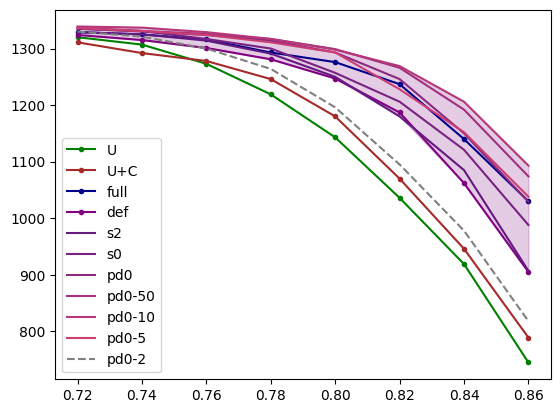

In [70]:
### others
trust_list_uni_min=np.percentile(trust_list_uni,10,axis=0)
trust_list_uniconch_min=np.percentile(trust_list_uniconch,10,axis=0)
trust_list_uniconchtda_min=np.percentile(trust_list_uniconchtda,10,axis=0)
###U+Ts
trust_list_default_min=np.percentile(trust_list_default,10,axis=0)
trust_list_sizetwo_min=np.percentile(trust_list_sizetwo,10,axis=0)
trust_list_sizezero_min=np.percentile(trust_list_sizezero,10,axis=0)
trust_list_pdzero_min=np.percentile(trust_list_pdzero,10,axis=0)
trust_list_pdzerohalf_min=np.percentile(trust_list_pdzerohalf,10,axis=0)
trust_list_pdzerotenpercent_min=np.percentile(trust_list_pdzerotenpercent,10,axis=0)
trust_list_pdzerofivepercent_min=np.percentile(trust_list_pdzerofivepercent,10,axis=0)
trust_list_pdzerotwopercent_min=np.percentile(trust_list_pdzerotwopercent,10,axis=0)
####################
stable_uni=[]
stable_uniconch=[]
stable_uniconchtda=[]
stable_default=[]
stable_sizetwo=[]
stable_sizezero=[]
stable_pdzero=[]
stable_pdzerohalf=[]
stable_pdzerotenpercent=[]
stable_pdzerofivepercent=[]
stable_pdzerotwopercent=[]
for trust_thres in np.arange(0,1,0.02):
    trust_spots_uni=np.where(trust_list_uni_min>trust_thres)[0]
    trust_spots_uniconch=np.where(trust_list_uniconch_min>trust_thres)[0]
    trust_spots_uniconchtda=np.where(trust_list_uniconchtda_min>trust_thres)[0]

    trust_spots_default=np.where(trust_list_default_min>trust_thres)[0]
    trust_spots_sizetwo=np.where(trust_list_sizetwo_min>trust_thres)[0]
    trust_spots_sizezero=np.where(trust_list_sizezero_min>trust_thres)[0]
    trust_spots_pdzero=np.where(trust_list_pdzero_min>trust_thres)[0]
    trust_spots_pdzerohalf=np.where(trust_list_pdzerohalf_min>trust_thres)[0]
    trust_spots_pdzerotenpercent=np.where(trust_list_pdzerotenpercent_min>trust_thres)[0]
    trust_spots_pdzerofivepercent=np.where(trust_list_pdzerofivepercent_min>trust_thres)[0]
    trust_spots_pdzerotwopercent=np.where(trust_list_pdzerotwopercent_min>trust_thres)[0]


    ### Record the number of stable points with each threshold value
    stable_uni.append(len(trust_spots_uni))
    stable_uniconch.append(len(trust_spots_uniconch))
    stable_uniconchtda.append(len(trust_spots_uniconchtda))

    stable_default.append(len(trust_spots_default))
    stable_sizetwo.append(len(trust_spots_sizetwo))
    stable_sizezero.append(len(trust_spots_sizezero))
    stable_pdzero.append(len(trust_spots_pdzero))
    stable_pdzerohalf.append(len(trust_spots_pdzerohalf))
    stable_pdzerotenpercent.append(len(trust_spots_pdzerotenpercent))
    stable_pdzerofivepercent.append(len(trust_spots_pdzerofivepercent))
    stable_pdzerotwopercent.append(len(trust_spots_pdzerotwopercent))
full_stable_list=np.array([stable_default,stable_sizetwo,stable_sizezero,stable_pdzero,stable_pdzerohalf,stable_pdzerotenpercent, stable_pdzerofivepercent,stable_pdzerotwopercent])
max_stable_list=np.max(full_stable_list,axis=0)
min_stable_list=np.min(full_stable_list,axis=0)
mask=np.where(max_stable_list>0.8*max_stable_list[0])
mask2=np.where(min_stable_list<0.99*min_stable_list[0])
mask3=np.intersect1d(mask[0],mask2[0])

utmulti_list=np.array([stable_default,stable_sizetwo,stable_sizezero,stable_pdzero,stable_pdzerohalf,stable_pdzerotenpercent, stable_pdzerofivepercent])
y_min=utmulti_list.min(axis=0)
y_max=utmulti_list.max(axis=0)

### Visualization
x=np.arange(0,1,0.02)[mask3]
plt.plot(x,np.array(stable_uni)[mask3],marker='.',label='U',color='green')
plt.plot(x,np.array(stable_uniconch)[mask3],marker='.',label='U+C',color='brown')
plt.plot(x,np.array(stable_uniconchtda)[mask3],marker='.',label='full',color="darkblue")

plt.plot(x,np.array(stable_default)[mask3],marker='.',label='def',color='purple')
plt.plot(x,np.array(stable_sizetwo)[mask3],label='s2',color=colors[0])
plt.plot(x,np.array(stable_sizezero)[mask3],label='s0',color=colors[1])
plt.plot(x,np.array(stable_pdzero)[mask3],label='pd0',color=colors[2])
plt.plot(x,np.array(stable_pdzerohalf)[mask3],label='pd0-50',color=colors[3])
plt.plot(x,np.array(stable_pdzerotenpercent)[mask3],label='pd0-10',color=colors[4])
plt.plot(x,np.array(stable_pdzerofivepercent)[mask3],label='pd0-5',color=colors[5])
plt.plot(x,np.array(stable_pdzerotwopercent)[mask3],label='pd0-2',color='gray',ls="--")
plt.fill_between(
    x,
    y_min[mask3],
    y_max[mask3],
    color='purple',
    alpha=0.2,
)

plt.legend()
plt.show()



### 1-percentile

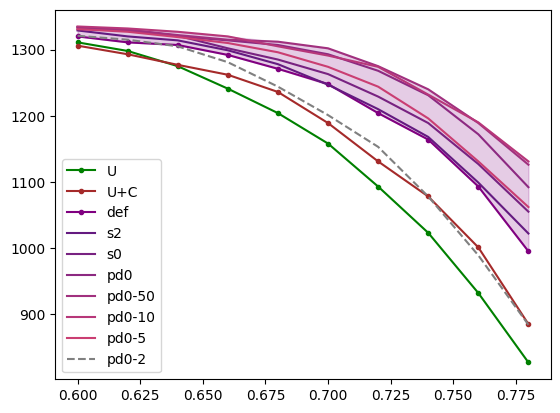

In [71]:
### others
trust_list_uni_min=np.percentile(trust_list_uni,1,axis=0)
trust_list_uniconch_min=np.percentile(trust_list_uniconch,1,axis=0)
trust_list_uniconchtda_min=np.percentile(trust_list_uniconchtda,1,axis=0)
###U+Ts
trust_list_default_min=np.percentile(trust_list_default,1,axis=0)
trust_list_sizetwo_min=np.percentile(trust_list_sizetwo,1,axis=0)
trust_list_sizezero_min=np.percentile(trust_list_sizezero,1,axis=0)
trust_list_pdzero_min=np.percentile(trust_list_pdzero,1,axis=0)
trust_list_pdzerohalf_min=np.percentile(trust_list_pdzerohalf,1,axis=0)
trust_list_pdzerotenpercent_min=np.percentile(trust_list_pdzerotenpercent,1,axis=0)
trust_list_pdzerofivepercent_min=np.percentile(trust_list_pdzerofivepercent,1,axis=0)
trust_list_pdzerotwopercent_min=np.percentile(trust_list_pdzerotwopercent,1,axis=0)
####################
stable_uni=[]
stable_uniconch=[]
stable_uniconchtda=[]
stable_default=[]
stable_sizetwo=[]
stable_sizezero=[]
stable_pdzero=[]
stable_pdzerohalf=[]
stable_pdzerotenpercent=[]
stable_pdzerofivepercent=[]
stable_pdzerotwopercent=[]
for trust_thres in np.arange(0,1,0.02):
    trust_spots_uni=np.where(trust_list_uni_min>trust_thres)[0]
    trust_spots_uniconch=np.where(trust_list_uniconch_min>trust_thres)[0]
    trust_spots_uniconchtda=np.where(trust_list_uniconchtda_min>trust_thres)[0]

    trust_spots_default=np.where(trust_list_default_min>trust_thres)[0]
    trust_spots_sizetwo=np.where(trust_list_sizetwo_min>trust_thres)[0]
    trust_spots_sizezero=np.where(trust_list_sizezero_min>trust_thres)[0]
    trust_spots_pdzero=np.where(trust_list_pdzero_min>trust_thres)[0]
    trust_spots_pdzerohalf=np.where(trust_list_pdzerohalf_min>trust_thres)[0]
    trust_spots_pdzerotenpercent=np.where(trust_list_pdzerotenpercent_min>trust_thres)[0]
    trust_spots_pdzerofivepercent=np.where(trust_list_pdzerofivepercent_min>trust_thres)[0]
    trust_spots_pdzerotwopercent=np.where(trust_list_pdzerotwopercent_min>trust_thres)[0]


    ### Record the number of stable points with each threshold value
    stable_uni.append(len(trust_spots_uni))
    stable_uniconch.append(len(trust_spots_uniconch))
    stable_uniconchtda.append(len(trust_spots_uniconchtda))

    stable_default.append(len(trust_spots_default))
    stable_sizetwo.append(len(trust_spots_sizetwo))
    stable_sizezero.append(len(trust_spots_sizezero))
    stable_pdzero.append(len(trust_spots_pdzero))
    stable_pdzerohalf.append(len(trust_spots_pdzerohalf))
    stable_pdzerotenpercent.append(len(trust_spots_pdzerotenpercent))
    stable_pdzerofivepercent.append(len(trust_spots_pdzerofivepercent))
    stable_pdzerotwopercent.append(len(trust_spots_pdzerotwopercent))
full_stable_list=np.array([stable_default,stable_sizetwo,stable_sizezero,stable_pdzero,stable_pdzerohalf,stable_pdzerotenpercent, stable_pdzerofivepercent,stable_pdzerotwopercent])
max_stable_list=np.max(full_stable_list,axis=0)
min_stable_list=np.min(full_stable_list,axis=0)
mask=np.where(max_stable_list>0.8*max_stable_list[0])
mask2=np.where(min_stable_list<0.99*min_stable_list[0])
mask3=np.intersect1d(mask[0],mask2[0])

utmulti_list=np.array([stable_default,stable_sizetwo,stable_sizezero,stable_pdzero,stable_pdzerohalf,stable_pdzerotenpercent, stable_pdzerofivepercent])
y_min=utmulti_list.min(axis=0)
y_max=utmulti_list.max(axis=0)

### Visualization
x=np.arange(0,1,0.02)[mask3]
plt.plot(x,np.array(stable_uni)[mask3],marker='.',label='U',color='green')
plt.plot(x,np.array(stable_uniconch)[mask3],marker='.',label='U+C',color='brown')
#plt.plot(x,np.array(stable_uniconchtda)[mask3],marker='.',label='full')

plt.plot(x,np.array(stable_default)[mask3],marker='.',label='def',color='purple')
plt.plot(x,np.array(stable_sizetwo)[mask3],label='s2',color=colors[0])
plt.plot(x,np.array(stable_sizezero)[mask3],label='s0',color=colors[1])
plt.plot(x,np.array(stable_pdzero)[mask3],label='pd0',color=colors[2])
plt.plot(x,np.array(stable_pdzerohalf)[mask3],label='pd0-50',color=colors[3])
plt.plot(x,np.array(stable_pdzerotenpercent)[mask3],label='pd0-10',color=colors[4])
plt.plot(x,np.array(stable_pdzerofivepercent)[mask3],label='pd0-5',color=colors[5])
plt.plot(x,np.array(stable_pdzerotwopercent)[mask3],label='pd0-2',color='gray',ls="--")
plt.fill_between(
    x,
    y_min[mask3],
    y_max[mask3],
    color='purple',
    alpha=0.2,
)

plt.legend()
plt.show()



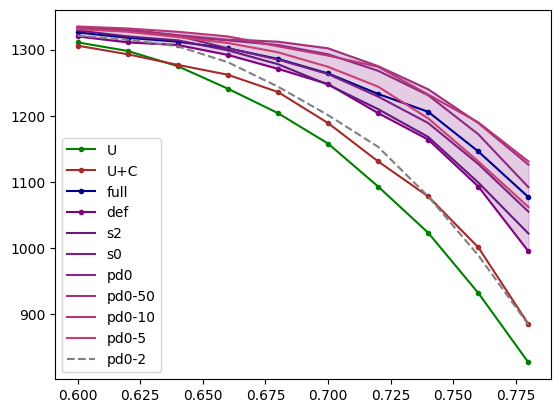

In [72]:
### others
trust_list_uni_min=np.percentile(trust_list_uni,1,axis=0)
trust_list_uniconch_min=np.percentile(trust_list_uniconch,1,axis=0)
trust_list_uniconchtda_min=np.percentile(trust_list_uniconchtda,1,axis=0)
###U+Ts
trust_list_default_min=np.percentile(trust_list_default,1,axis=0)
trust_list_sizetwo_min=np.percentile(trust_list_sizetwo,1,axis=0)
trust_list_sizezero_min=np.percentile(trust_list_sizezero,1,axis=0)
trust_list_pdzero_min=np.percentile(trust_list_pdzero,1,axis=0)
trust_list_pdzerohalf_min=np.percentile(trust_list_pdzerohalf,1,axis=0)
trust_list_pdzerotenpercent_min=np.percentile(trust_list_pdzerotenpercent,1,axis=0)
trust_list_pdzerofivepercent_min=np.percentile(trust_list_pdzerofivepercent,1,axis=0)
trust_list_pdzerotwopercent_min=np.percentile(trust_list_pdzerotwopercent,1,axis=0)
####################
stable_uni=[]
stable_uniconch=[]
stable_uniconchtda=[]
stable_default=[]
stable_sizetwo=[]
stable_sizezero=[]
stable_pdzero=[]
stable_pdzerohalf=[]
stable_pdzerotenpercent=[]
stable_pdzerofivepercent=[]
stable_pdzerotwopercent=[]
for trust_thres in np.arange(0,1,0.02):
    trust_spots_uni=np.where(trust_list_uni_min>trust_thres)[0]
    trust_spots_uniconch=np.where(trust_list_uniconch_min>trust_thres)[0]
    trust_spots_uniconchtda=np.where(trust_list_uniconchtda_min>trust_thres)[0]

    trust_spots_default=np.where(trust_list_default_min>trust_thres)[0]
    trust_spots_sizetwo=np.where(trust_list_sizetwo_min>trust_thres)[0]
    trust_spots_sizezero=np.where(trust_list_sizezero_min>trust_thres)[0]
    trust_spots_pdzero=np.where(trust_list_pdzero_min>trust_thres)[0]
    trust_spots_pdzerohalf=np.where(trust_list_pdzerohalf_min>trust_thres)[0]
    trust_spots_pdzerotenpercent=np.where(trust_list_pdzerotenpercent_min>trust_thres)[0]
    trust_spots_pdzerofivepercent=np.where(trust_list_pdzerofivepercent_min>trust_thres)[0]
    trust_spots_pdzerotwopercent=np.where(trust_list_pdzerotwopercent_min>trust_thres)[0]


    ### Record the number of stable points with each threshold value
    stable_uni.append(len(trust_spots_uni))
    stable_uniconch.append(len(trust_spots_uniconch))
    stable_uniconchtda.append(len(trust_spots_uniconchtda))

    stable_default.append(len(trust_spots_default))
    stable_sizetwo.append(len(trust_spots_sizetwo))
    stable_sizezero.append(len(trust_spots_sizezero))
    stable_pdzero.append(len(trust_spots_pdzero))
    stable_pdzerohalf.append(len(trust_spots_pdzerohalf))
    stable_pdzerotenpercent.append(len(trust_spots_pdzerotenpercent))
    stable_pdzerofivepercent.append(len(trust_spots_pdzerofivepercent))
    stable_pdzerotwopercent.append(len(trust_spots_pdzerotwopercent))
full_stable_list=np.array([stable_default,stable_sizetwo,stable_sizezero,stable_pdzero,stable_pdzerohalf,stable_pdzerotenpercent, stable_pdzerofivepercent,stable_pdzerotwopercent])
max_stable_list=np.max(full_stable_list,axis=0)
min_stable_list=np.min(full_stable_list,axis=0)
mask=np.where(max_stable_list>0.8*max_stable_list[0])
mask2=np.where(min_stable_list<0.99*min_stable_list[0])
mask3=np.intersect1d(mask[0],mask2[0])

utmulti_list=np.array([stable_default,stable_sizetwo,stable_sizezero,stable_pdzero,stable_pdzerohalf,stable_pdzerotenpercent, stable_pdzerofivepercent])
y_min=utmulti_list.min(axis=0)
y_max=utmulti_list.max(axis=0)

### Visualization
x=np.arange(0,1,0.02)[mask3]
plt.plot(x,np.array(stable_uni)[mask3],marker='.',label='U',color='green')
plt.plot(x,np.array(stable_uniconch)[mask3],marker='.',label='U+C',color='brown')
plt.plot(x,np.array(stable_uniconchtda)[mask3],marker='.',label='full',color="darkblue")

plt.plot(x,np.array(stable_default)[mask3],marker='.',label='def',color='purple')
plt.plot(x,np.array(stable_sizetwo)[mask3],label='s2',color=colors[0])
plt.plot(x,np.array(stable_sizezero)[mask3],label='s0',color=colors[1])
plt.plot(x,np.array(stable_pdzero)[mask3],label='pd0',color=colors[2])
plt.plot(x,np.array(stable_pdzerohalf)[mask3],label='pd0-50',color=colors[3])
plt.plot(x,np.array(stable_pdzerotenpercent)[mask3],label='pd0-10',color=colors[4])
plt.plot(x,np.array(stable_pdzerofivepercent)[mask3],label='pd0-5',color=colors[5])
plt.plot(x,np.array(stable_pdzerotwopercent)[mask3],label='pd0-2',color='gray',ls="--")
plt.fill_between(
    x,
    y_min[mask3],
    y_max[mask3],
    color='purple',
    alpha=0.2,
)

plt.legend()
plt.show()



### 5-percentile

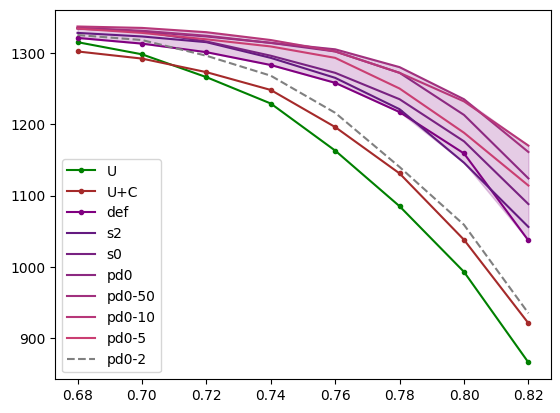

In [73]:
### others
trust_list_uni_min=np.percentile(trust_list_uni,5,axis=0)
trust_list_uniconch_min=np.percentile(trust_list_uniconch,5,axis=0)
trust_list_uniconchtda_min=np.percentile(trust_list_uniconchtda,5,axis=0)
###U+Ts
trust_list_default_min=np.percentile(trust_list_default,5,axis=0)
trust_list_sizetwo_min=np.percentile(trust_list_sizetwo,5,axis=0)
trust_list_sizezero_min=np.percentile(trust_list_sizezero,5,axis=0)
trust_list_pdzero_min=np.percentile(trust_list_pdzero,5,axis=0)
trust_list_pdzerohalf_min=np.percentile(trust_list_pdzerohalf,5,axis=0)
trust_list_pdzerotenpercent_min=np.percentile(trust_list_pdzerotenpercent,5,axis=0)
trust_list_pdzerofivepercent_min=np.percentile(trust_list_pdzerofivepercent,5,axis=0)
trust_list_pdzerotwopercent_min=np.percentile(trust_list_pdzerotwopercent,5,axis=0)
####################
stable_uni=[]
stable_uniconch=[]
stable_uniconchtda=[]
stable_default=[]
stable_sizetwo=[]
stable_sizezero=[]
stable_pdzero=[]
stable_pdzerohalf=[]
stable_pdzerotenpercent=[]
stable_pdzerofivepercent=[]
stable_pdzerotwopercent=[]
for trust_thres in np.arange(0,1,0.02):
    trust_spots_uni=np.where(trust_list_uni_min>trust_thres)[0]
    trust_spots_uniconch=np.where(trust_list_uniconch_min>trust_thres)[0]
    trust_spots_uniconchtda=np.where(trust_list_uniconchtda_min>trust_thres)[0]

    trust_spots_default=np.where(trust_list_default_min>trust_thres)[0]
    trust_spots_sizetwo=np.where(trust_list_sizetwo_min>trust_thres)[0]
    trust_spots_sizezero=np.where(trust_list_sizezero_min>trust_thres)[0]
    trust_spots_pdzero=np.where(trust_list_pdzero_min>trust_thres)[0]
    trust_spots_pdzerohalf=np.where(trust_list_pdzerohalf_min>trust_thres)[0]
    trust_spots_pdzerotenpercent=np.where(trust_list_pdzerotenpercent_min>trust_thres)[0]
    trust_spots_pdzerofivepercent=np.where(trust_list_pdzerofivepercent_min>trust_thres)[0]
    trust_spots_pdzerotwopercent=np.where(trust_list_pdzerotwopercent_min>trust_thres)[0]


    ### Record the number of stable points with each threshold value
    stable_uni.append(len(trust_spots_uni))
    stable_uniconch.append(len(trust_spots_uniconch))
    stable_uniconchtda.append(len(trust_spots_uniconchtda))

    stable_default.append(len(trust_spots_default))
    stable_sizetwo.append(len(trust_spots_sizetwo))
    stable_sizezero.append(len(trust_spots_sizezero))
    stable_pdzero.append(len(trust_spots_pdzero))
    stable_pdzerohalf.append(len(trust_spots_pdzerohalf))
    stable_pdzerotenpercent.append(len(trust_spots_pdzerotenpercent))
    stable_pdzerofivepercent.append(len(trust_spots_pdzerofivepercent))
    stable_pdzerotwopercent.append(len(trust_spots_pdzerotwopercent))
full_stable_list=np.array([stable_default,stable_sizetwo,stable_sizezero,stable_pdzero,stable_pdzerohalf,stable_pdzerotenpercent, stable_pdzerofivepercent,stable_pdzerotwopercent])
max_stable_list=np.max(full_stable_list,axis=0)
min_stable_list=np.min(full_stable_list,axis=0)
mask=np.where(max_stable_list>0.8*max_stable_list[0])
mask2=np.where(min_stable_list<0.99*min_stable_list[0])
mask3=np.intersect1d(mask[0],mask2[0])

utmulti_list=np.array([stable_default,stable_sizetwo,stable_sizezero,stable_pdzero,stable_pdzerohalf,stable_pdzerotenpercent, stable_pdzerofivepercent])
y_min=utmulti_list.min(axis=0)
y_max=utmulti_list.max(axis=0)

### Visualization
x=np.arange(0,1,0.02)[mask3]
plt.plot(x,np.array(stable_uni)[mask3],marker='.',label='U',color='green')
plt.plot(x,np.array(stable_uniconch)[mask3],marker='.',label='U+C',color='brown')
#plt.plot(x,np.array(stable_uniconchtda)[mask3],marker='.',label='full')

plt.plot(x,np.array(stable_default)[mask3],marker='.',label='def',color='purple')
plt.plot(x,np.array(stable_sizetwo)[mask3],label='s2',color=colors[0])
plt.plot(x,np.array(stable_sizezero)[mask3],label='s0',color=colors[1])
plt.plot(x,np.array(stable_pdzero)[mask3],label='pd0',color=colors[2])
plt.plot(x,np.array(stable_pdzerohalf)[mask3],label='pd0-50',color=colors[3])
plt.plot(x,np.array(stable_pdzerotenpercent)[mask3],label='pd0-10',color=colors[4])
plt.plot(x,np.array(stable_pdzerofivepercent)[mask3],label='pd0-5',color=colors[5])
plt.plot(x,np.array(stable_pdzerotwopercent)[mask3],label='pd0-2',color='gray',ls="--")
plt.fill_between(
    x,
    y_min[mask3],
    y_max[mask3],
    color='purple',
    alpha=0.2,
)

plt.legend()
plt.show()



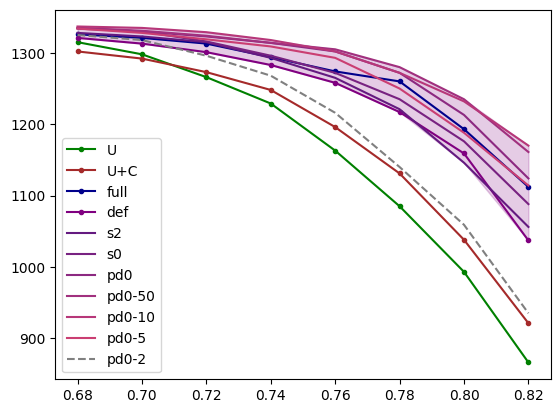

In [74]:
### others
trust_list_uni_min=np.percentile(trust_list_uni,5,axis=0)
trust_list_uniconch_min=np.percentile(trust_list_uniconch,5,axis=0)
trust_list_uniconchtda_min=np.percentile(trust_list_uniconchtda,5,axis=0)
###U+Ts
trust_list_default_min=np.percentile(trust_list_default,5,axis=0)
trust_list_sizetwo_min=np.percentile(trust_list_sizetwo,5,axis=0)
trust_list_sizezero_min=np.percentile(trust_list_sizezero,5,axis=0)
trust_list_pdzero_min=np.percentile(trust_list_pdzero,5,axis=0)
trust_list_pdzerohalf_min=np.percentile(trust_list_pdzerohalf,5,axis=0)
trust_list_pdzerotenpercent_min=np.percentile(trust_list_pdzerotenpercent,5,axis=0)
trust_list_pdzerofivepercent_min=np.percentile(trust_list_pdzerofivepercent,5,axis=0)
trust_list_pdzerotwopercent_min=np.percentile(trust_list_pdzerotwopercent,5,axis=0)
####################
stable_uni=[]
stable_uniconch=[]
stable_uniconchtda=[]
stable_default=[]
stable_sizetwo=[]
stable_sizezero=[]
stable_pdzero=[]
stable_pdzerohalf=[]
stable_pdzerotenpercent=[]
stable_pdzerofivepercent=[]
stable_pdzerotwopercent=[]
for trust_thres in np.arange(0,1,0.02):
    trust_spots_uni=np.where(trust_list_uni_min>trust_thres)[0]
    trust_spots_uniconch=np.where(trust_list_uniconch_min>trust_thres)[0]
    trust_spots_uniconchtda=np.where(trust_list_uniconchtda_min>trust_thres)[0]

    trust_spots_default=np.where(trust_list_default_min>trust_thres)[0]
    trust_spots_sizetwo=np.where(trust_list_sizetwo_min>trust_thres)[0]
    trust_spots_sizezero=np.where(trust_list_sizezero_min>trust_thres)[0]
    trust_spots_pdzero=np.where(trust_list_pdzero_min>trust_thres)[0]
    trust_spots_pdzerohalf=np.where(trust_list_pdzerohalf_min>trust_thres)[0]
    trust_spots_pdzerotenpercent=np.where(trust_list_pdzerotenpercent_min>trust_thres)[0]
    trust_spots_pdzerofivepercent=np.where(trust_list_pdzerofivepercent_min>trust_thres)[0]
    trust_spots_pdzerotwopercent=np.where(trust_list_pdzerotwopercent_min>trust_thres)[0]


    ### Record the number of stable points with each threshold value
    stable_uni.append(len(trust_spots_uni))
    stable_uniconch.append(len(trust_spots_uniconch))
    stable_uniconchtda.append(len(trust_spots_uniconchtda))

    stable_default.append(len(trust_spots_default))
    stable_sizetwo.append(len(trust_spots_sizetwo))
    stable_sizezero.append(len(trust_spots_sizezero))
    stable_pdzero.append(len(trust_spots_pdzero))
    stable_pdzerohalf.append(len(trust_spots_pdzerohalf))
    stable_pdzerotenpercent.append(len(trust_spots_pdzerotenpercent))
    stable_pdzerofivepercent.append(len(trust_spots_pdzerofivepercent))
    stable_pdzerotwopercent.append(len(trust_spots_pdzerotwopercent))
full_stable_list=np.array([stable_default,stable_sizetwo,stable_sizezero,stable_pdzero,stable_pdzerohalf,stable_pdzerotenpercent, stable_pdzerofivepercent,stable_pdzerotwopercent])
max_stable_list=np.max(full_stable_list,axis=0)
min_stable_list=np.min(full_stable_list,axis=0)
mask=np.where(max_stable_list>0.8*max_stable_list[0])
mask2=np.where(min_stable_list<0.99*min_stable_list[0])
mask3=np.intersect1d(mask[0],mask2[0])

utmulti_list=np.array([stable_default,stable_sizetwo,stable_sizezero,stable_pdzero,stable_pdzerohalf,stable_pdzerotenpercent, stable_pdzerofivepercent])
y_min=utmulti_list.min(axis=0)
y_max=utmulti_list.max(axis=0)

### Visualization
x=np.arange(0,1,0.02)[mask3]
plt.plot(x,np.array(stable_uni)[mask3],marker='.',label='U',color='green')
plt.plot(x,np.array(stable_uniconch)[mask3],marker='.',label='U+C',color='brown')
plt.plot(x,np.array(stable_uniconchtda)[mask3],marker='.',label='full',color="darkblue")

plt.plot(x,np.array(stable_default)[mask3],marker='.',label='def',color='purple')
plt.plot(x,np.array(stable_sizetwo)[mask3],label='s2',color=colors[0])
plt.plot(x,np.array(stable_sizezero)[mask3],label='s0',color=colors[1])
plt.plot(x,np.array(stable_pdzero)[mask3],label='pd0',color=colors[2])
plt.plot(x,np.array(stable_pdzerohalf)[mask3],label='pd0-50',color=colors[3])
plt.plot(x,np.array(stable_pdzerotenpercent)[mask3],label='pd0-10',color=colors[4])
plt.plot(x,np.array(stable_pdzerofivepercent)[mask3],label='pd0-5',color=colors[5])
plt.plot(x,np.array(stable_pdzerotwopercent)[mask3],label='pd0-2',color='gray',ls="--")
plt.fill_between(
    x,
    y_min[mask3],
    y_max[mask3],
    color='purple',
    alpha=0.2,
)

plt.legend()
plt.show()



### U+T band was consistently above U. Although U+C entered the lower part at p=0, in all other p's, U+T band was above U+C.